In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_splitting import split_val_train, split_and_plot_classes
from src.model import RegresionLineal, logistic_regression, SMOTE
from src.auxiliares import (
    codificar_categoricas,
    visualizar_distribuciones,
    preprocesar_imputado,
    imputar_dataset,
    entrenar_con_lambda_optimo,
    tratamiento_nan,
    calc_roc_pr,
    get_prob_positiva
)
from src.metrics import (
    matriz_confusion,
    plot_curves,
    accuracy,
    precision,
    recall,
    f1_score_manual,
    auc_trapecio,
)
warnings.filterwarnings("ignore")

Realizar un análisis exploratorio del dataset de desarrollocell_diagnosis_balanced_dev.csv. Visualizar la distribución de las variables,identificar valores faltantes, outliers y variables categóricas. Investigar los rangosposibles de cada feature y analizar su correlación con el target. 


In [2]:
data= pd.read_csv('data/raw/cell_diagnosis_balanced_dev.csv')
data= pd.DataFrame(data)

#calculo los valores nan del dataset, nos sirve para analizar luego que podemos hacer con ellos segun la cantidad que sean y en que features.
print('valores nulos en cada columna:\n', data.isna().sum()) #cuantos valores nulos hay en cada columna
print('cantidad de filas totales del dataset:',len(data)) #cuantas filas hay en total
print('cantidad de filas del dataset',data.isna().any(axis=1).sum()) #cuantas filas tienen al menos un valor nulo

valores nulos en cada columna:
 CellSize               330
CellShape              316
NucleusDensity         301
ChromatinTexture       297
CytoplasmSize          316
CellAdhesion           294
MitosisRate            320
NuclearMembrane        320
GrowthFactor           304
OxygenSaturation       288
Vascularization        316
InflammationMarkers    305
Diagnosis                0
CellType               256
GeneticMutation          0
dtype: int64
cantidad de filas totales del dataset: 1663
cantidad de filas del dataset 1538


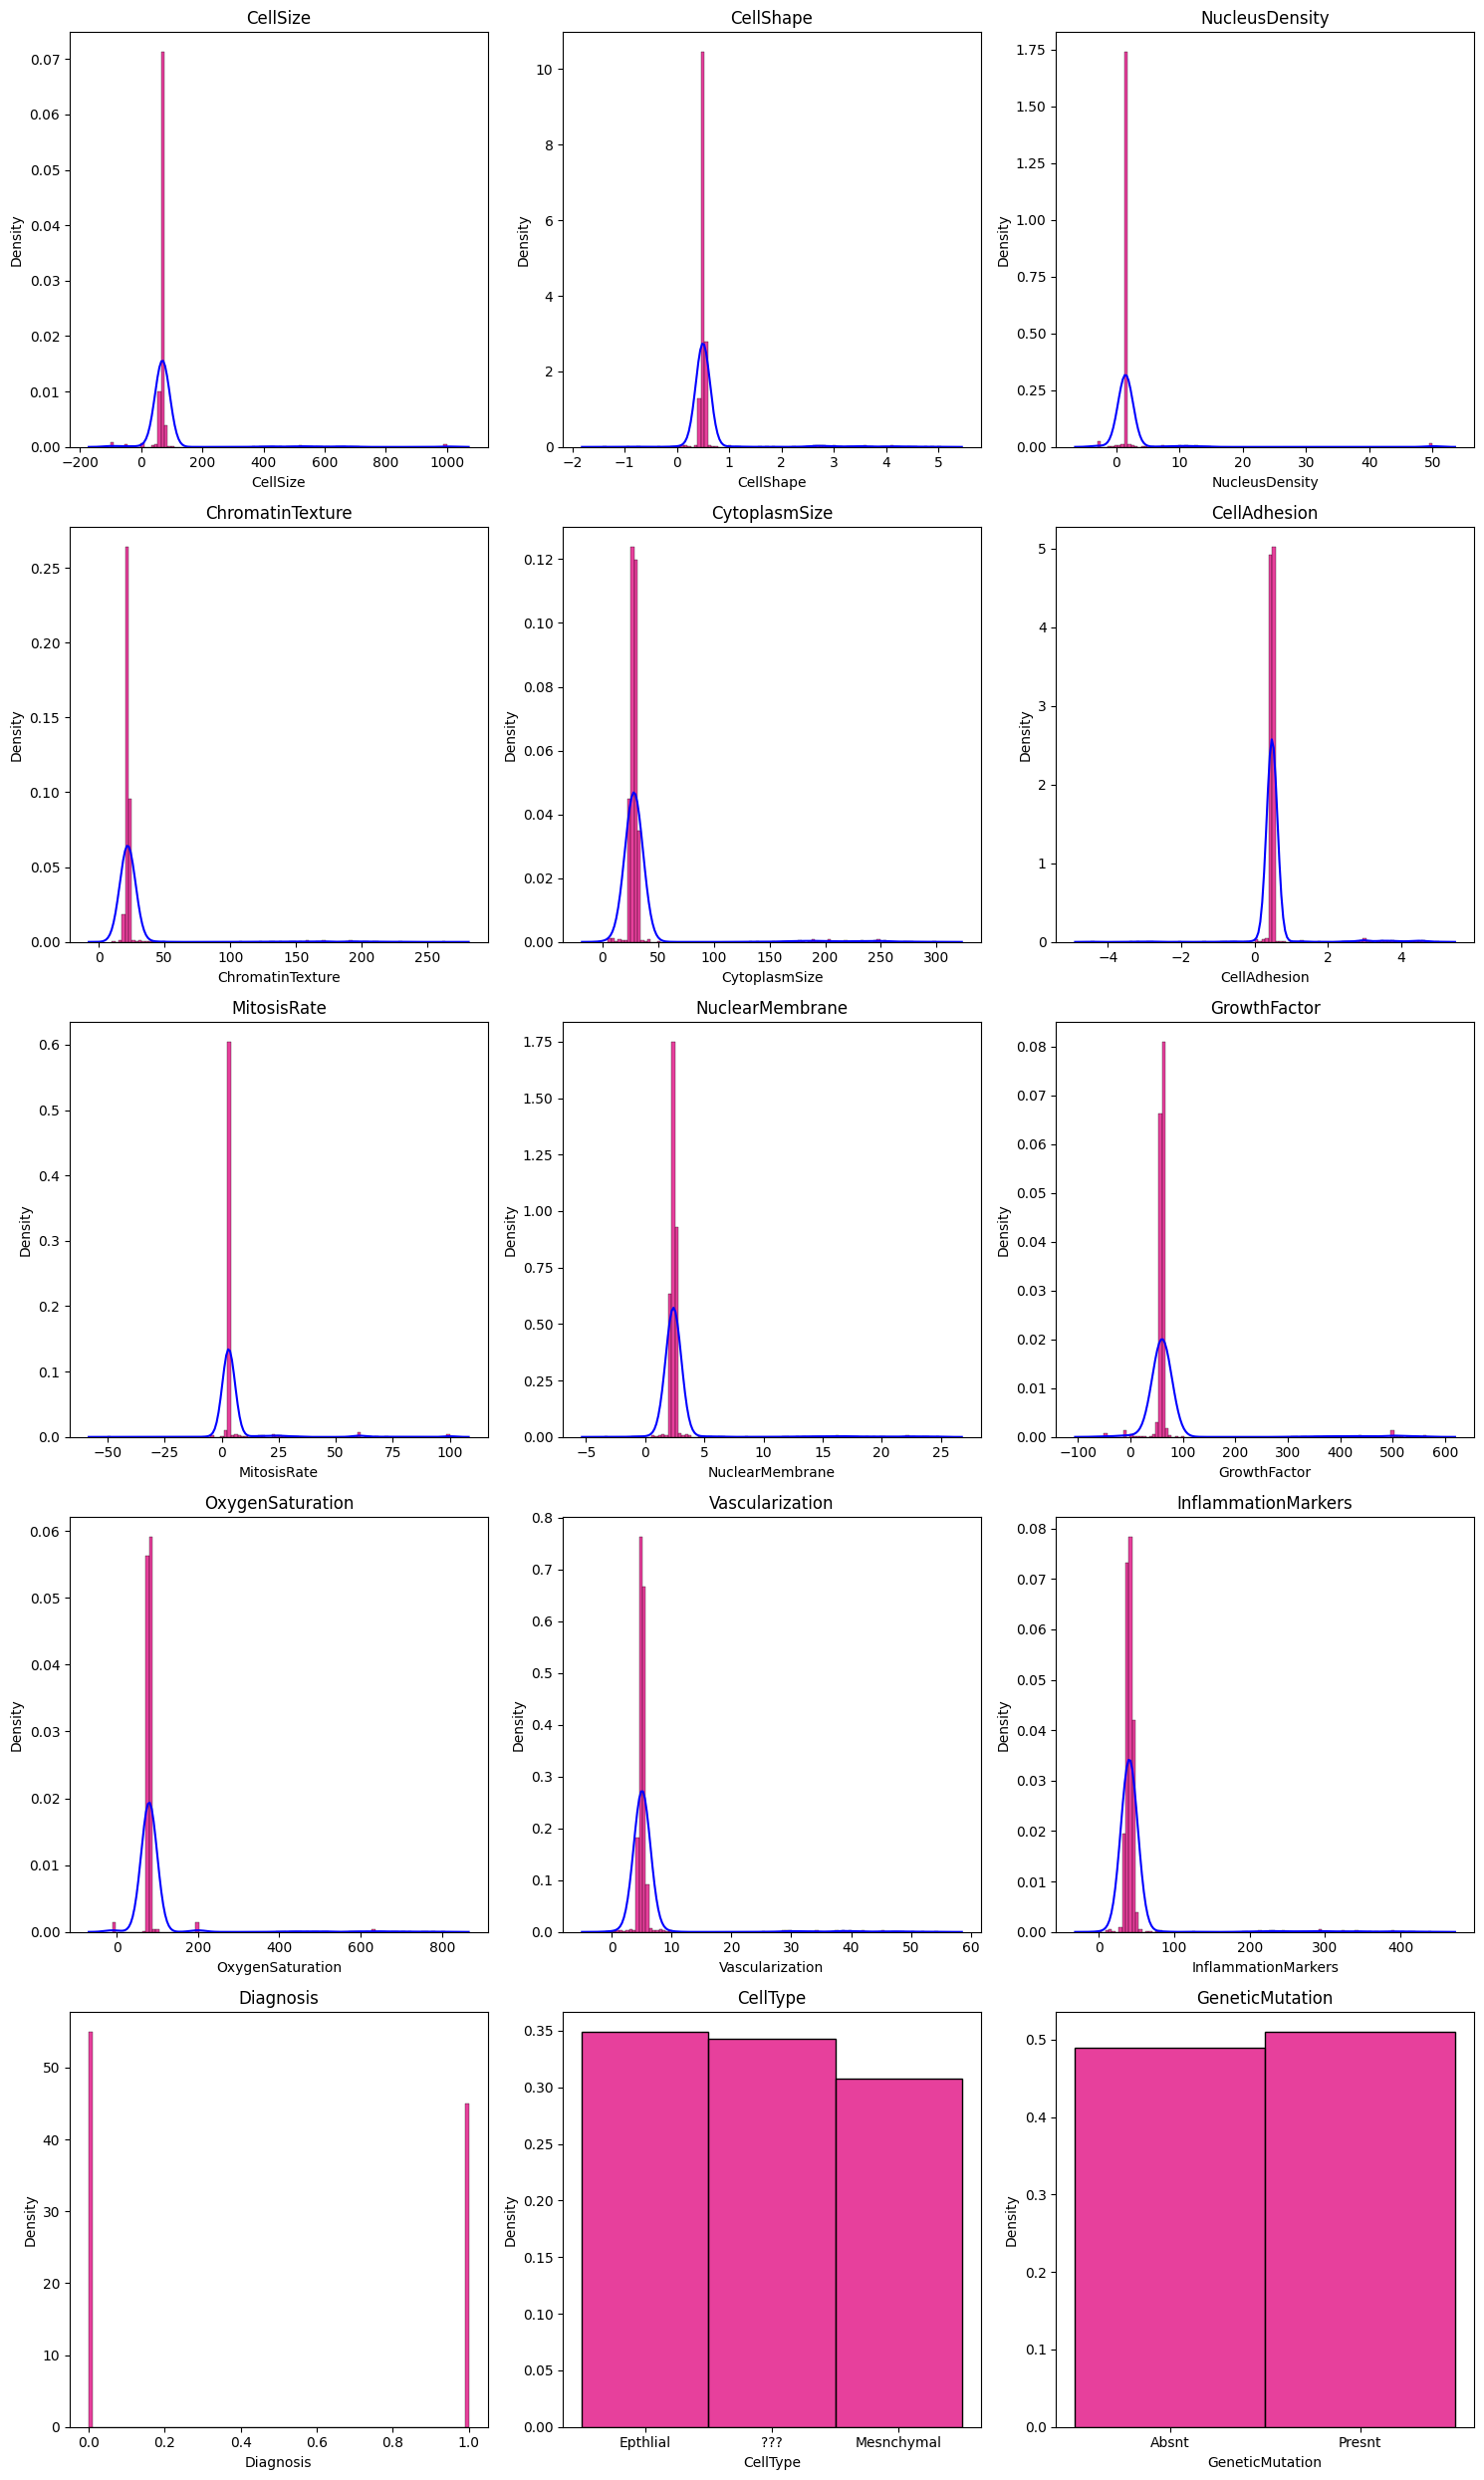

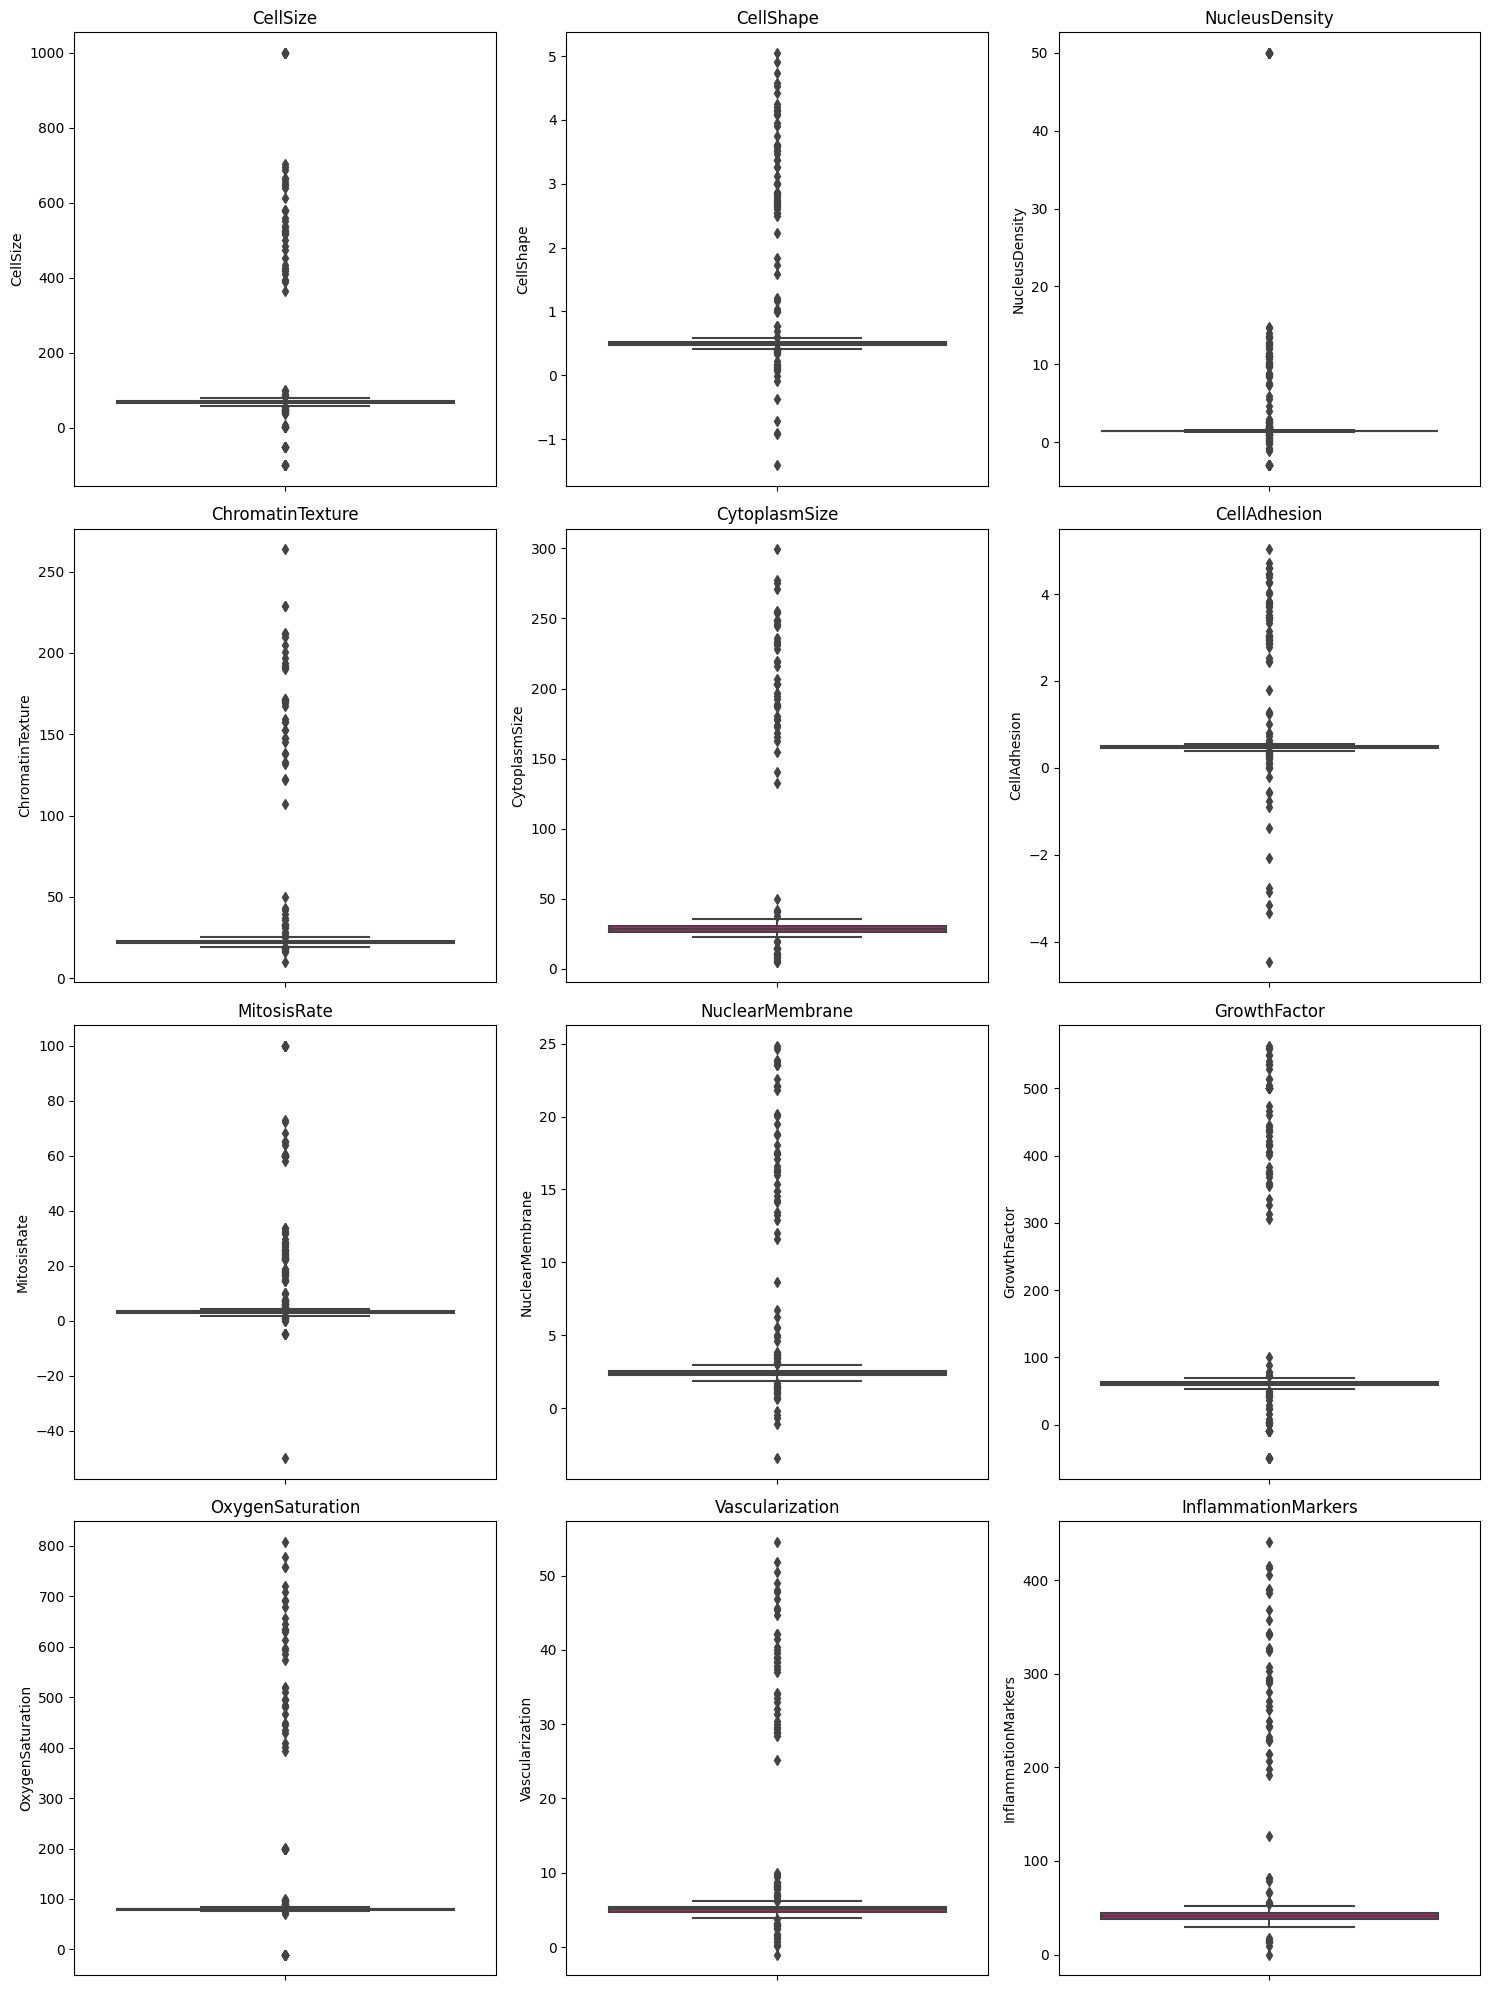

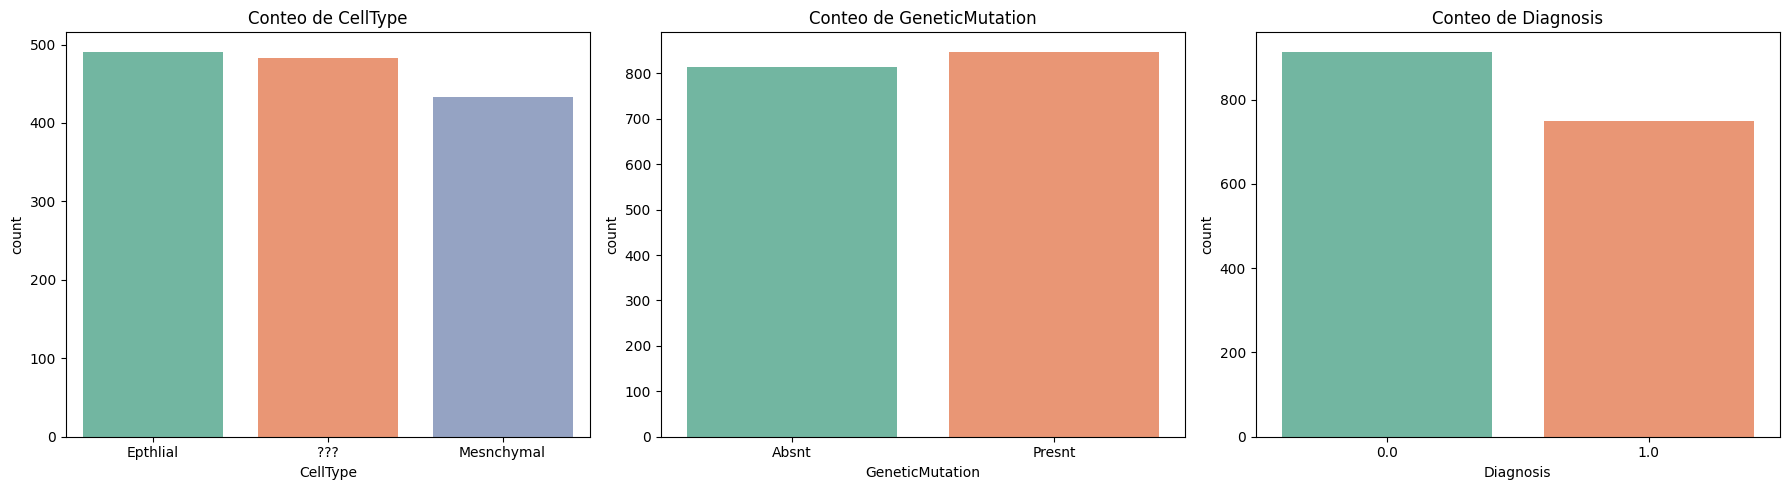

In [3]:
visualizar_distribuciones(data)

En los boxplots se pueden ver valores atipicos identificados en variables como CellSize, CellShape, NucleusDensity, ChromatinTexture, CytoplasmSize, GrowthFactor y OxygenSaturation, los cuales se alejan significativamente del rango tipico de los datos.  Estos datos pueden distorsionar estadisticas como la media y la desviacion estandar, afectando la normalizacion y modelos sensibles a outliers. Es por esto que se decide eliminarlos.

Dividir el dataset en un 80 % para entrenamiento y un 20 % para validación.
Estos conjuntos se utilizarán a lo largo de este ejercicio para entrenar y evaluar
los modelos.

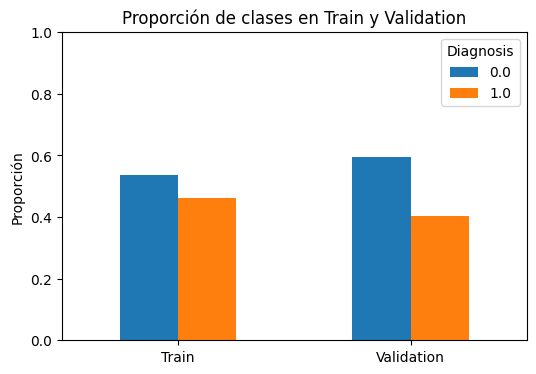

In [4]:
X_train, X_val, y_train, y_val, train_df, val_df = split_and_plot_classes(data, target_column='Diagnosis', test_size=0.2)

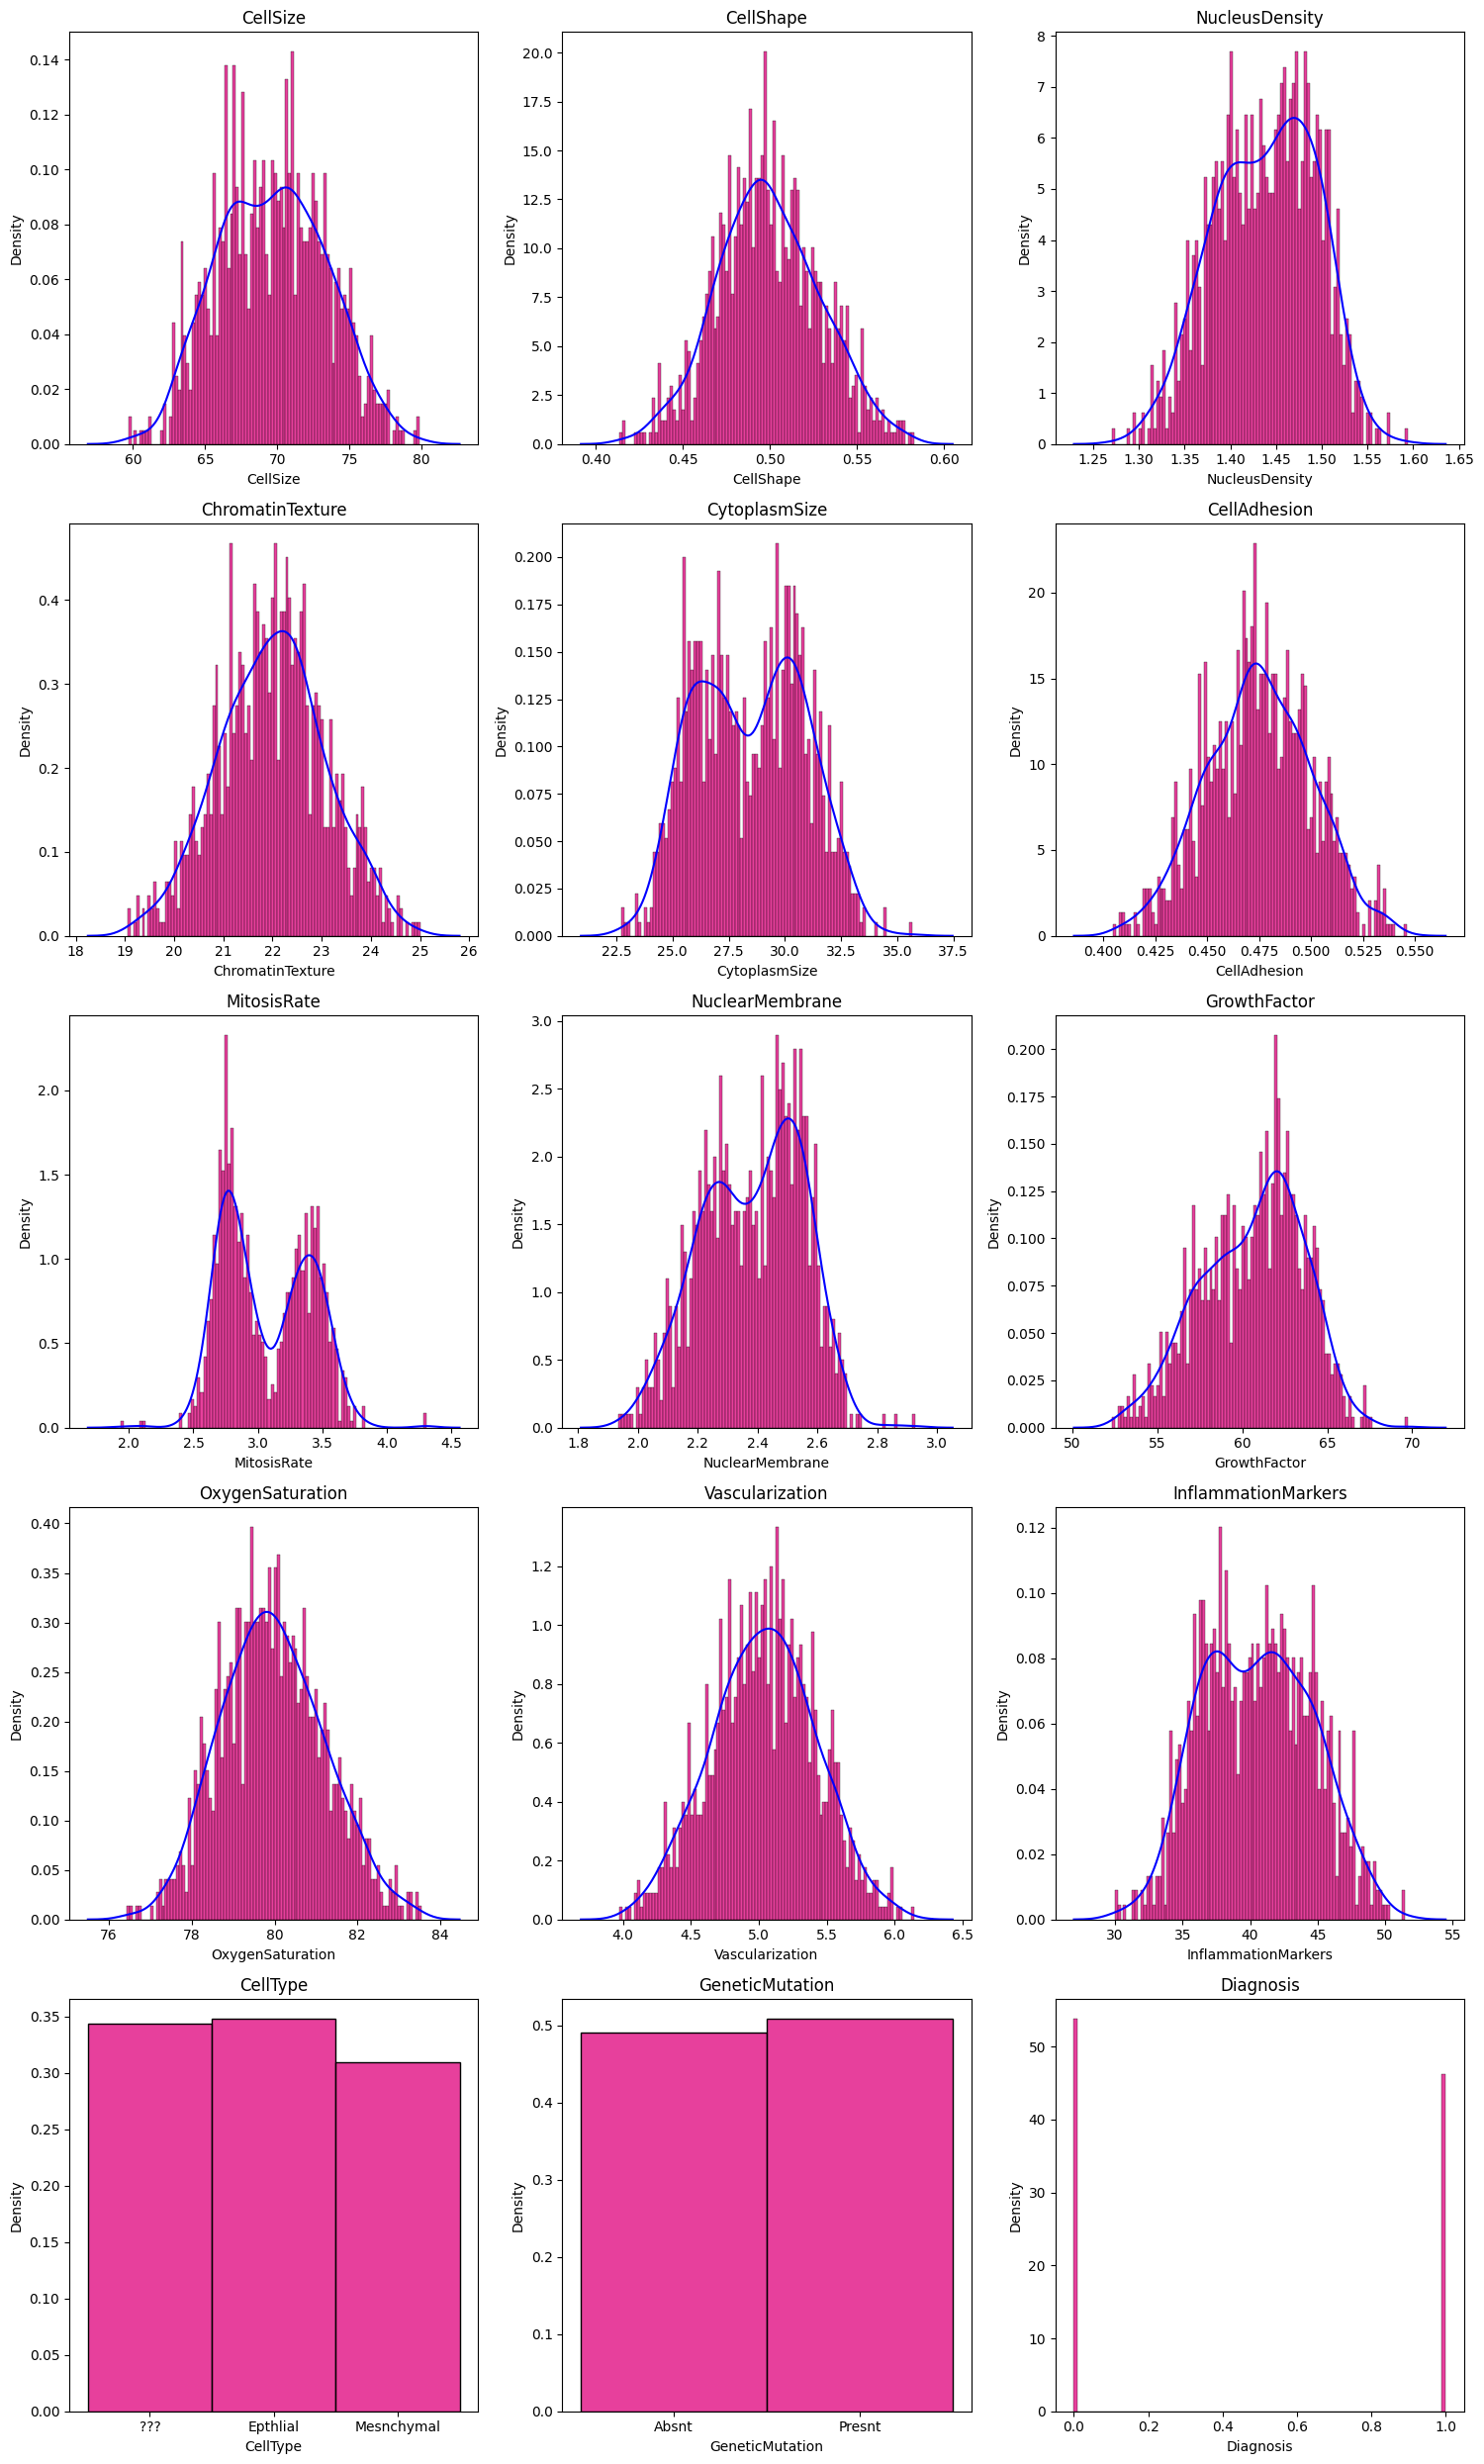

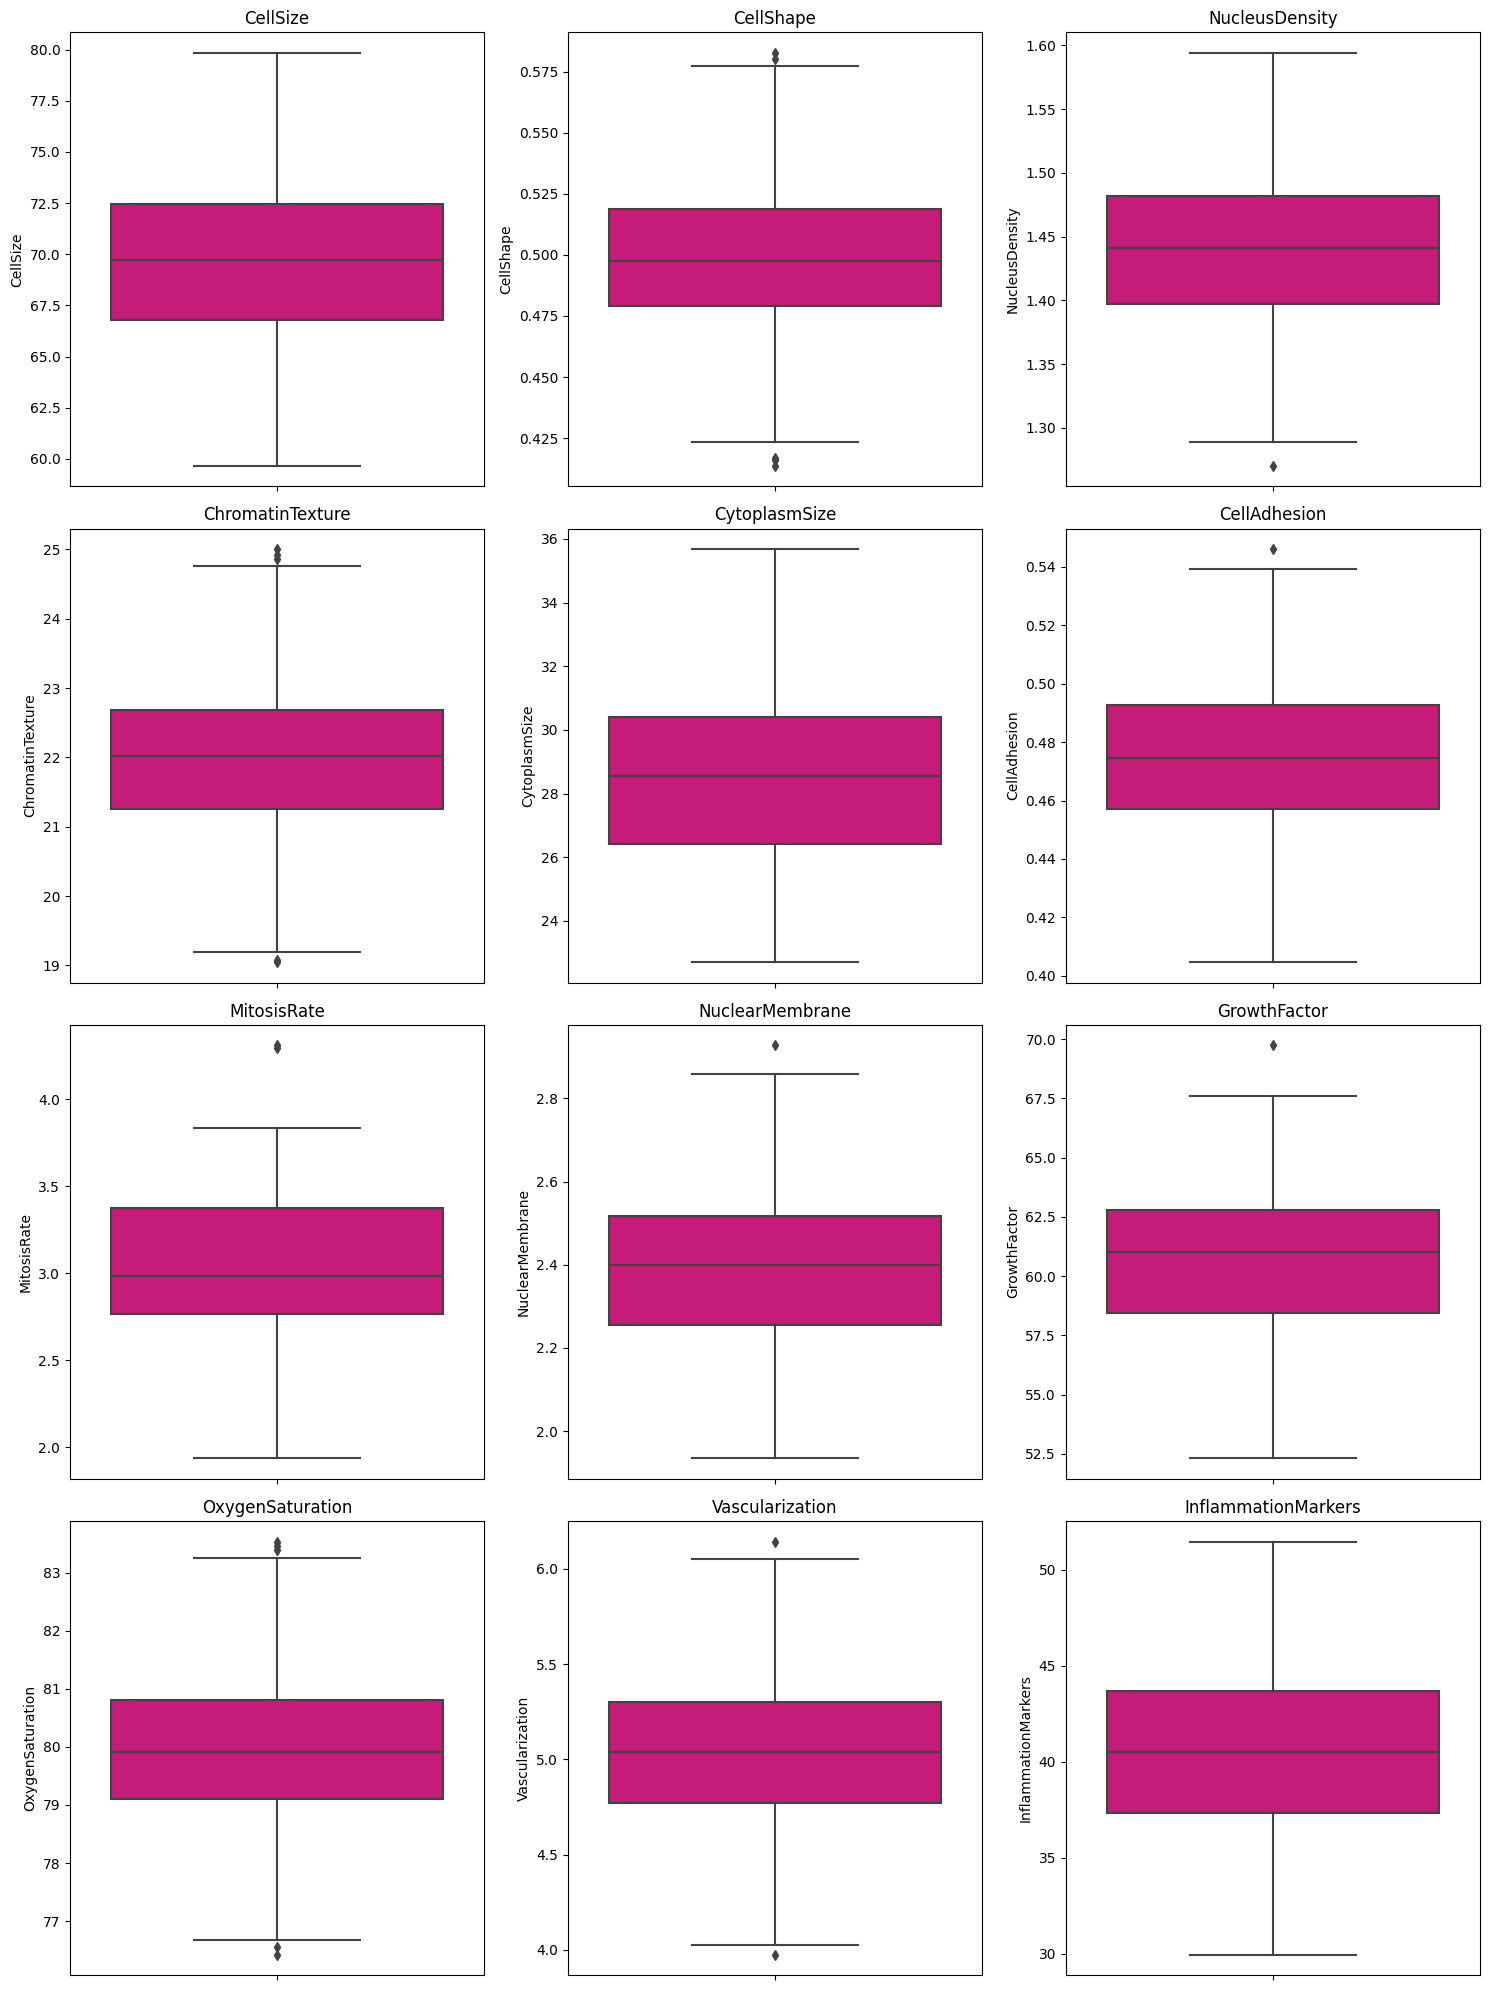

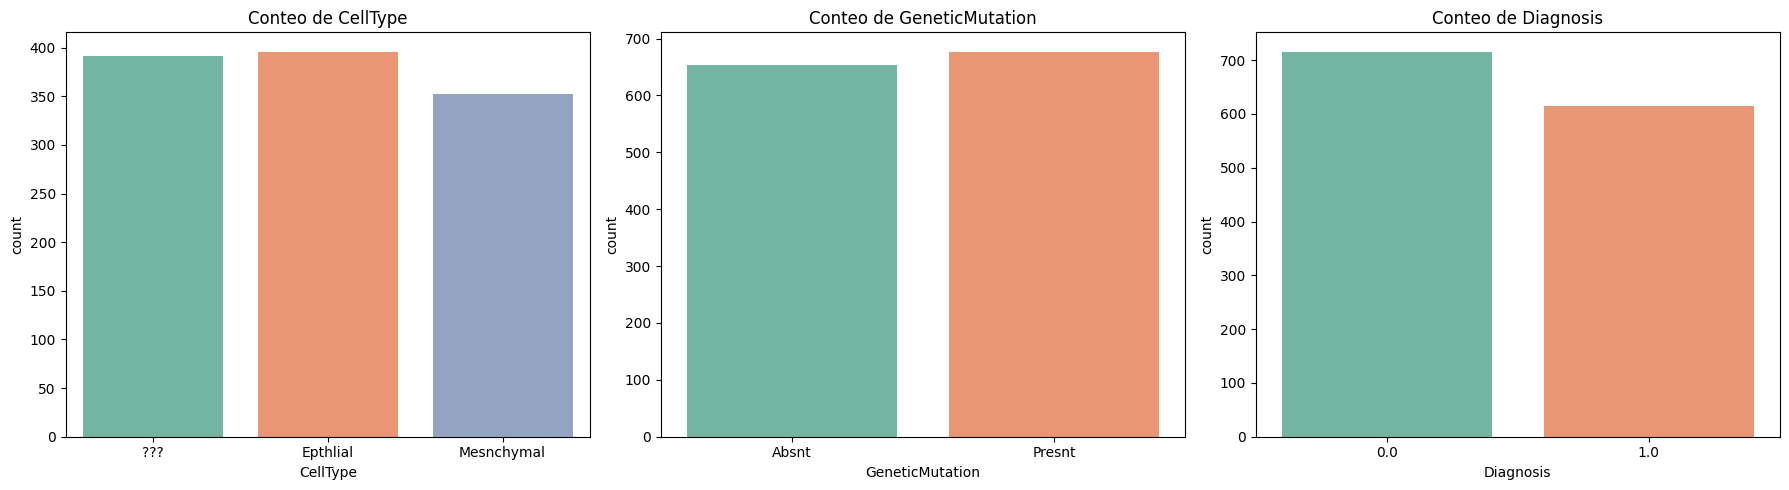

In [5]:
numericas = ['CellSize','CellShape','NucleusDensity','ChromatinTexture','CytoplasmSize',
             'CellAdhesion','MitosisRate','NuclearMembrane','GrowthFactor','OxygenSaturation',
             'Vascularization','InflammationMarkers']
categoricas = ["CellType", "GeneticMutation", "Diagnosis"]

#eliminar outliers
train_num = X_train[numericas]
val_num = X_val[numericas]

Q1 = train_num.quantile(0.25)
Q3 = train_num.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
train_num_clean = train_num.mask((train_num < lower_bound) | (train_num > upper_bound))
val_num_clean = val_num.mask((val_num < lower_bound) | (val_num > upper_bound))

X_train_outliers = pd.concat([train_num_clean, X_train[categoricas[:-1]]], axis=1)
X_val_outliers   = pd.concat([val_num_clean, X_val[categoricas[:-1]]], axis=1)

train_outliers = pd.concat([X_train_outliers, y_train], axis=1)
val_outliers   = pd.concat([X_val_outliers, y_val], axis=1)

visualizar_distribuciones(train_outliers, categoricas=categoricas, columnas=3)

Aplicar las tecnicas de limpieza y preprocesamiento que considere necesarias, justificando sus decisiones. No se espera la eliminación masiva de observaciones salvo
que exista una razón sólida y bien documentada. Tener especial cuidado de evitar
data leakage al aplicar las transformaciones.



Mejor lambda: 0.0001, F1=0.9052

Matriz de Confusion:
 [[14  2]
 [ 0  6]]
Accuracy: 0.9090909090909091
Precision (macro): 0.875
Recall (macro): 0.9375
F1-Score (macro): 0.9051724137431629
AUC-ROC Clase 0: 0.9688
AUC-ROC Clase 1: 0.9688
AUC-PR Clase 0: 0.9274
AUC-PR Clase 1: 0.7395


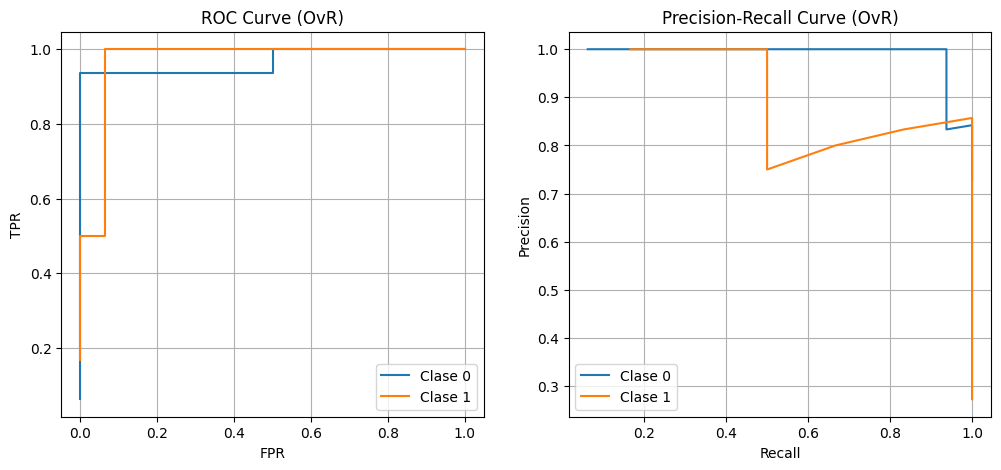

In [6]:
train_sin_nan, val_sin_nan, mean_train_nan, std_train_nan = tratamiento_nan(train_df, val_df, target_column='Diagnosis')
X_train = train_sin_nan.drop(columns=['Diagnosis']).values
y_train = train_sin_nan['Diagnosis'].values.astype(int)
X_val   = val_sin_nan.drop(columns=['Diagnosis']).values
y_val   = val_sin_nan['Diagnosis'].values.astype(int)
num_classes = len(np.unique(y_train))

W, b, y_pred, predict_proba_fn, y_score, best_lambda = entrenar_con_lambda_optimo(
    X_train, y_train, X_val, y_val
)

print("\nMatriz de Confusion:\n", matriz_confusion(y_val, y_pred, num_classes))
print("Accuracy:", accuracy(y_val, y_pred))
print("Precision (macro):", precision(y_val, y_pred))
print("Recall (macro):", recall(y_val, y_pred))
print("F1-Score (macro):", f1_score_manual(y_val, y_pred))

plot_curves(y_val, y_score, num_classes)

Debido a la cantidad de datos faltantes vistos en el analisis anterior, surgen dos formas de abordar este problema. La primera consiste en eliminar todas las filas que contengan NaN, con el riesgo de quedarnos con un dataset muy chico con pocas muestras para entrenar. Por otro lado, la otra opcion es imputar los datos. Al ser un dataset de un tema medico y muy especifico de este area, se debe tener cuidado porque quizas se imputan valores que no tienen sentido para una columna en particular (por ejemplo, usar una media o una mediana). Es por esto que se decidió, para un segundo tratamiento, imputar usando una regresión lineal que toma como parametro las columnas más correlacionadas con la columna que presenta un faltante. De esta manera, para cada valor ausente se predice su valor basado en la relacion lineal con las caracteristicas mas relevantes, evitando reemplazos arbitrarios y preservando la estructura estadistica del dataset. Para columnas categoricas o con pocos valores posibles, como "CellType" o "GeneticMutation", se opto por usar la moda, mientras que para columnas numericas con distribución concentrada, como "NucleusDensity" o "MitosisRate", se utilizo la mediana.


Mejor lambda: 0.0001, F1=0.9134

Matriz de Confusión:
 [[175  23]
 [  6 128]]
Accuracy: 0.9126506024096386
Precision (macro): 0.9072664739672899
Recall (macro): 0.9195311322176993
F1-Score (macro): 0.9133576321318578
AUC-ROC Clase 0: 0.9324
AUC-ROC Clase 1: 0.9324
AUC-PR Clase 0: 0.9623
AUC-PR Clase 1: 0.8210


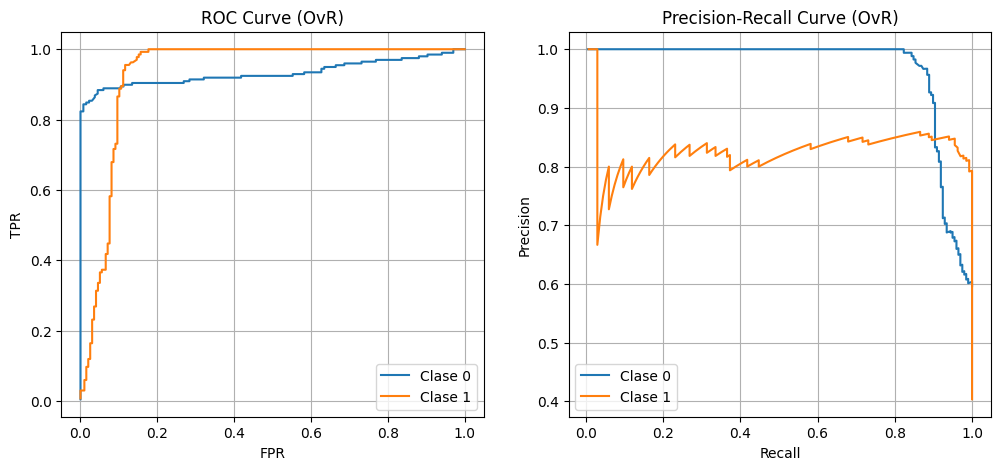

In [7]:
#entrenamiento para segundo dataset
train_outliers = codificar_categoricas(train_outliers)
val_outliers   = codificar_categoricas(val_outliers)
X_train = train_outliers.drop(columns=['Diagnosis'])
X_val   = val_outliers.drop(columns=['Diagnosis'])
y_train = train_outliers['Diagnosis']
y_val   = val_outliers['Diagnosis']
corr_matrix = X_train.corr(numeric_only=True)
X_train_imp, X_val_imp = imputar_dataset(X_train, X_val, corr_matrix, k=1)
train_imputado = pd.concat([X_train_imp, y_train], axis=1).dropna().reset_index(drop=True)
val_imputado   = pd.concat([X_val_imp, y_val], axis=1).dropna().reset_index(drop=True)
cols_num = train_imputado.select_dtypes(include=[np.number]).columns
cols_a_estandarizar = [c for c in cols_num if c not in ['CellType', 'GeneticMutation', 'Diagnosis']]

mean_train = train_imputado[cols_a_estandarizar].mean()
std_train  = train_imputado[cols_a_estandarizar].std()

train_imputado[cols_a_estandarizar] = (train_imputado[cols_a_estandarizar] - mean_train) / std_train
val_imputado[cols_a_estandarizar]   = (val_imputado[cols_a_estandarizar] - mean_train) / std_train

X_train_imp = train_imputado.drop(columns=['Diagnosis']).values
y_train_imp = train_imputado['Diagnosis'].values.astype(int)
X_val_imp   = val_imputado.drop(columns=['Diagnosis']).values
y_val_imp   = val_imputado['Diagnosis'].values.astype(int)

num_classes = len(np.unique(y_train))

W, b, y_pred, predict_proba_fn, y_score, best_lambda_imp = entrenar_con_lambda_optimo(
    X_train_imp, y_train_imp, X_val_imp, y_val_imp
)

y_pred_classes = (y_pred >= 0.5).astype(int)
print("\nMatriz de Confusión:\n", matriz_confusion(y_val_imp, y_pred_classes, num_classes))
print("Accuracy:", accuracy(y_val_imp, y_pred_classes))
print("Precision (macro):", precision(y_val_imp, y_pred_classes))
print("Recall (macro):", recall(y_val_imp, y_pred_classes))
print("F1-Score (macro):", f1_score_manual(y_val_imp, y_pred_classes))


plot_curves(y_val_imp, y_score, num_classes)

La metrica recall indica la proporcion de casos malignos correctamente identificados, lo que ayuda a minimizar los falsos negativos, especialmente importantes en este problema, ya que un falso negativo podria implicar que un paciente no reciba el tratamiento adecuado. Por otro lado, la precision refleja la proporcion de predicciones positivas que son realmente malignas, permitiendo controlar los falsos positivos y evitar procedimientos innecesarios o preocupaciones clinicas. Por esto es necesario priorizar un balance entre recall y precision. El F1 penaliza modelos que prioricen exclusivamente uno de los dos criterios y proporciona una medida mas representativa del desempeno global en la clase critica. Por esta razon, optimizar el hiperparametro de regularizacion lambda en funcion del F1 permite ajustar el modelo para maximizar la deteccion de tumores malignos mientras se mantiene bajo control el numero de falsos positivos, garantizando asi un desempeno clinico mas confiable que el que se obtendria utilizando unicamente la accuracy.

Utilizando el conjunto de datos de test cell_diagnosis_balanced_test.csv,
evalúe la performance del modelo desarrollado anteriormente computando las métricas de performance indicadas en el inciso 1.4.


=== Metricas TEST - Modelo sin NaN ===
Matriz de Confusion:
 [[8 0]
 [0 5]]
Accuracy: 1.0
Precision (macro): 1.0
Recall (macro): 1.0
F1-Score (macro): 0.99999999995
AUC-ROC Clase 0: 1.0000
AUC-ROC Clase 1: 1.0000
AUC-PR Clase 0: 0.8750
AUC-PR Clase 1: 0.8000


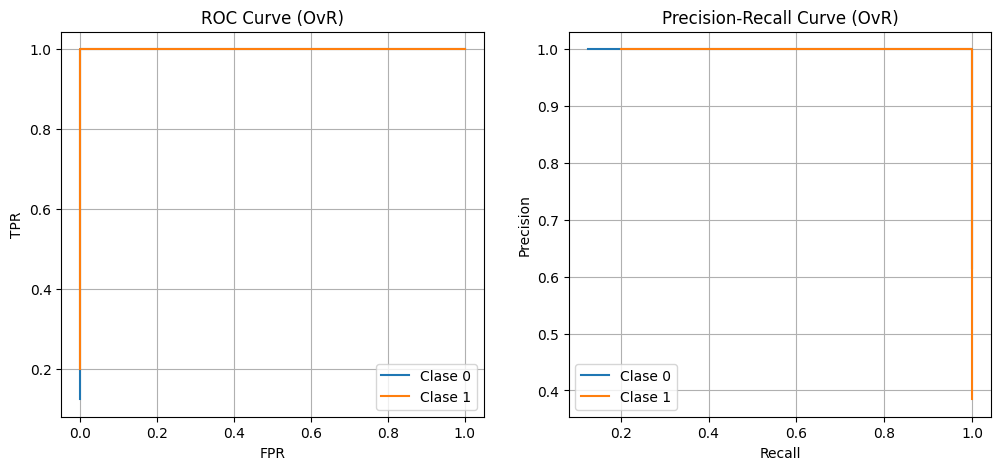


=== Metricas TEST - Modelo imputado ===
Matriz de Confusion:
 [[96  6]
 [ 8 75]]
Accuracy: 0.9243243243243243
Precision (macro): 0.9245014245014245
Recall (macro): 0.9223954642097802
F1-Score (macro): 0.9234472436244012
AUC-ROC Clase 0: 0.9489
AUC-ROC Clase 1: 0.9489
AUC-PR Clase 0: 0.9520
AUC-PR Clase 1: 0.8914


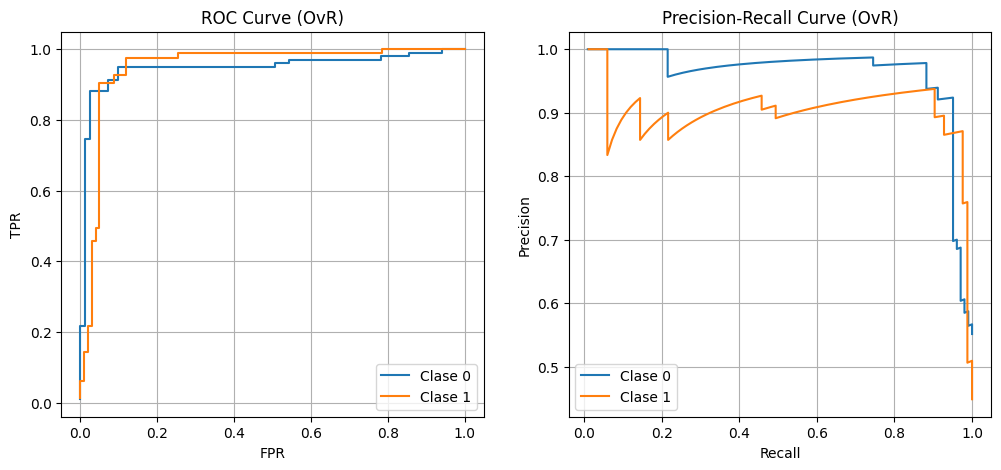

In [8]:
#evaluo para ambos modelos el dataset de testeo
train = pd.read_csv("data/raw/cell_diagnosis_balanced_dev.csv")
test  = pd.read_csv('data/raw/cell_diagnosis_balanced_test.csv')
train_sin_nan, test_sin_nan, mean_train_nan, std_train_nan = tratamiento_nan(train, test, target_column='Diagnosis')
X_train = train_sin_nan.drop(columns=['Diagnosis']).values
y_train = train_sin_nan['Diagnosis'].values.astype(int)
X_test  = test_sin_nan.drop(columns=['Diagnosis']).values
y_test  = test_sin_nan['Diagnosis'].values.astype(int)
num_classes = len(np.unique(y_train))
W_imp, b_imp, y_pred, predict_proba_fn_imp = logistic_regression(X_train=X_train, y_train=y_train,X_test=X_test, lr=0.01, epochs=10000,reg_lambda=best_lambda)
y_score = predict_proba_fn_imp(X_test)
print("\n=== Metricas TEST - Modelo sin NaN ===")
print("Matriz de Confusion:\n", matriz_confusion(y_test, y_pred, num_classes))
print("Accuracy:", accuracy(y_test, y_pred))
print("Precision (macro):", precision(y_test, y_pred))
print("Recall (macro):", recall(y_test, y_pred))
print("F1-Score (macro):", f1_score_manual(y_test, y_pred))
plot_curves(y_test, y_score, num_classes)
##############################################################################
train = pd.read_csv("data/raw/cell_diagnosis_balanced_dev.csv")
test  = pd.read_csv("data/raw/cell_diagnosis_balanced_test.csv")
X_train_imp, y_train_imp, X_test_imp, y_test_imp, train_df_proc, test_df_proc = preprocesar_imputado(train, test, numericas, categoricas, target='Diagnosis', k=1)
W_imp, b_imp, y_pred_imp, predict_proba_fn_imp = logistic_regression(X_train=X_train_imp, y_train=y_train_imp,X_test=X_test_imp, lr=0.01, epochs=10000,reg_lambda=best_lambda_imp)
y_score_imp = predict_proba_fn_imp(X_test_imp)
print("\n=== Metricas TEST - Modelo imputado ===")
print("Matriz de Confusion:\n", matriz_confusion(y_test_imp, y_pred_imp, num_classes))
print("Accuracy:", accuracy(y_test_imp, y_pred_imp))
print("Precision (macro):", precision(y_test_imp, y_pred_imp))
print("Recall (macro):", recall(y_test_imp, y_pred_imp))
print("F1-Score (macro):", f1_score_manual(y_test_imp, y_pred_imp))

plot_curves(y_test_imp, y_score_imp, num_classes)


Ambos modelos presentan un desempeño satisfactorio. No obstante, el accuracy igual a 1.0 observado en el modelo sin NaN resulta poco confiable, dado que el conjunto de prueba consta unicamente de 13 muestras. Es probable que el resultado optimo se deba a la coincidencia con estas pocas observaciones, por lo que no se puede considerar representativo de un rendimiento robusto del modelo.

 Rebalanceo de Clases en Conjuntos Desbalanceados:

Utilizando el conjunto de datos de desarrollo cell_diagnosis_imbalanced_dev.csv,
repita los pasos de exploración, división y preprocesamiento indicados en los incisos 1.1 a 1.3.

valores nulos en cada columna:
 CellSize               236
CellShape              237
NucleusDensity         220
ChromatinTexture       212
CytoplasmSize          245
CellAdhesion           214
MitosisRate            240
NuclearMembrane        225
GrowthFactor           230
OxygenSaturation       220
Vascularization        230
InflammationMarkers    219
Diagnosis                0
CellType               184
GeneticMutation          0
dtype: int64
cantidad de filas totales del dataset: 1218
cantidad de filas del dataset con NaN 1126


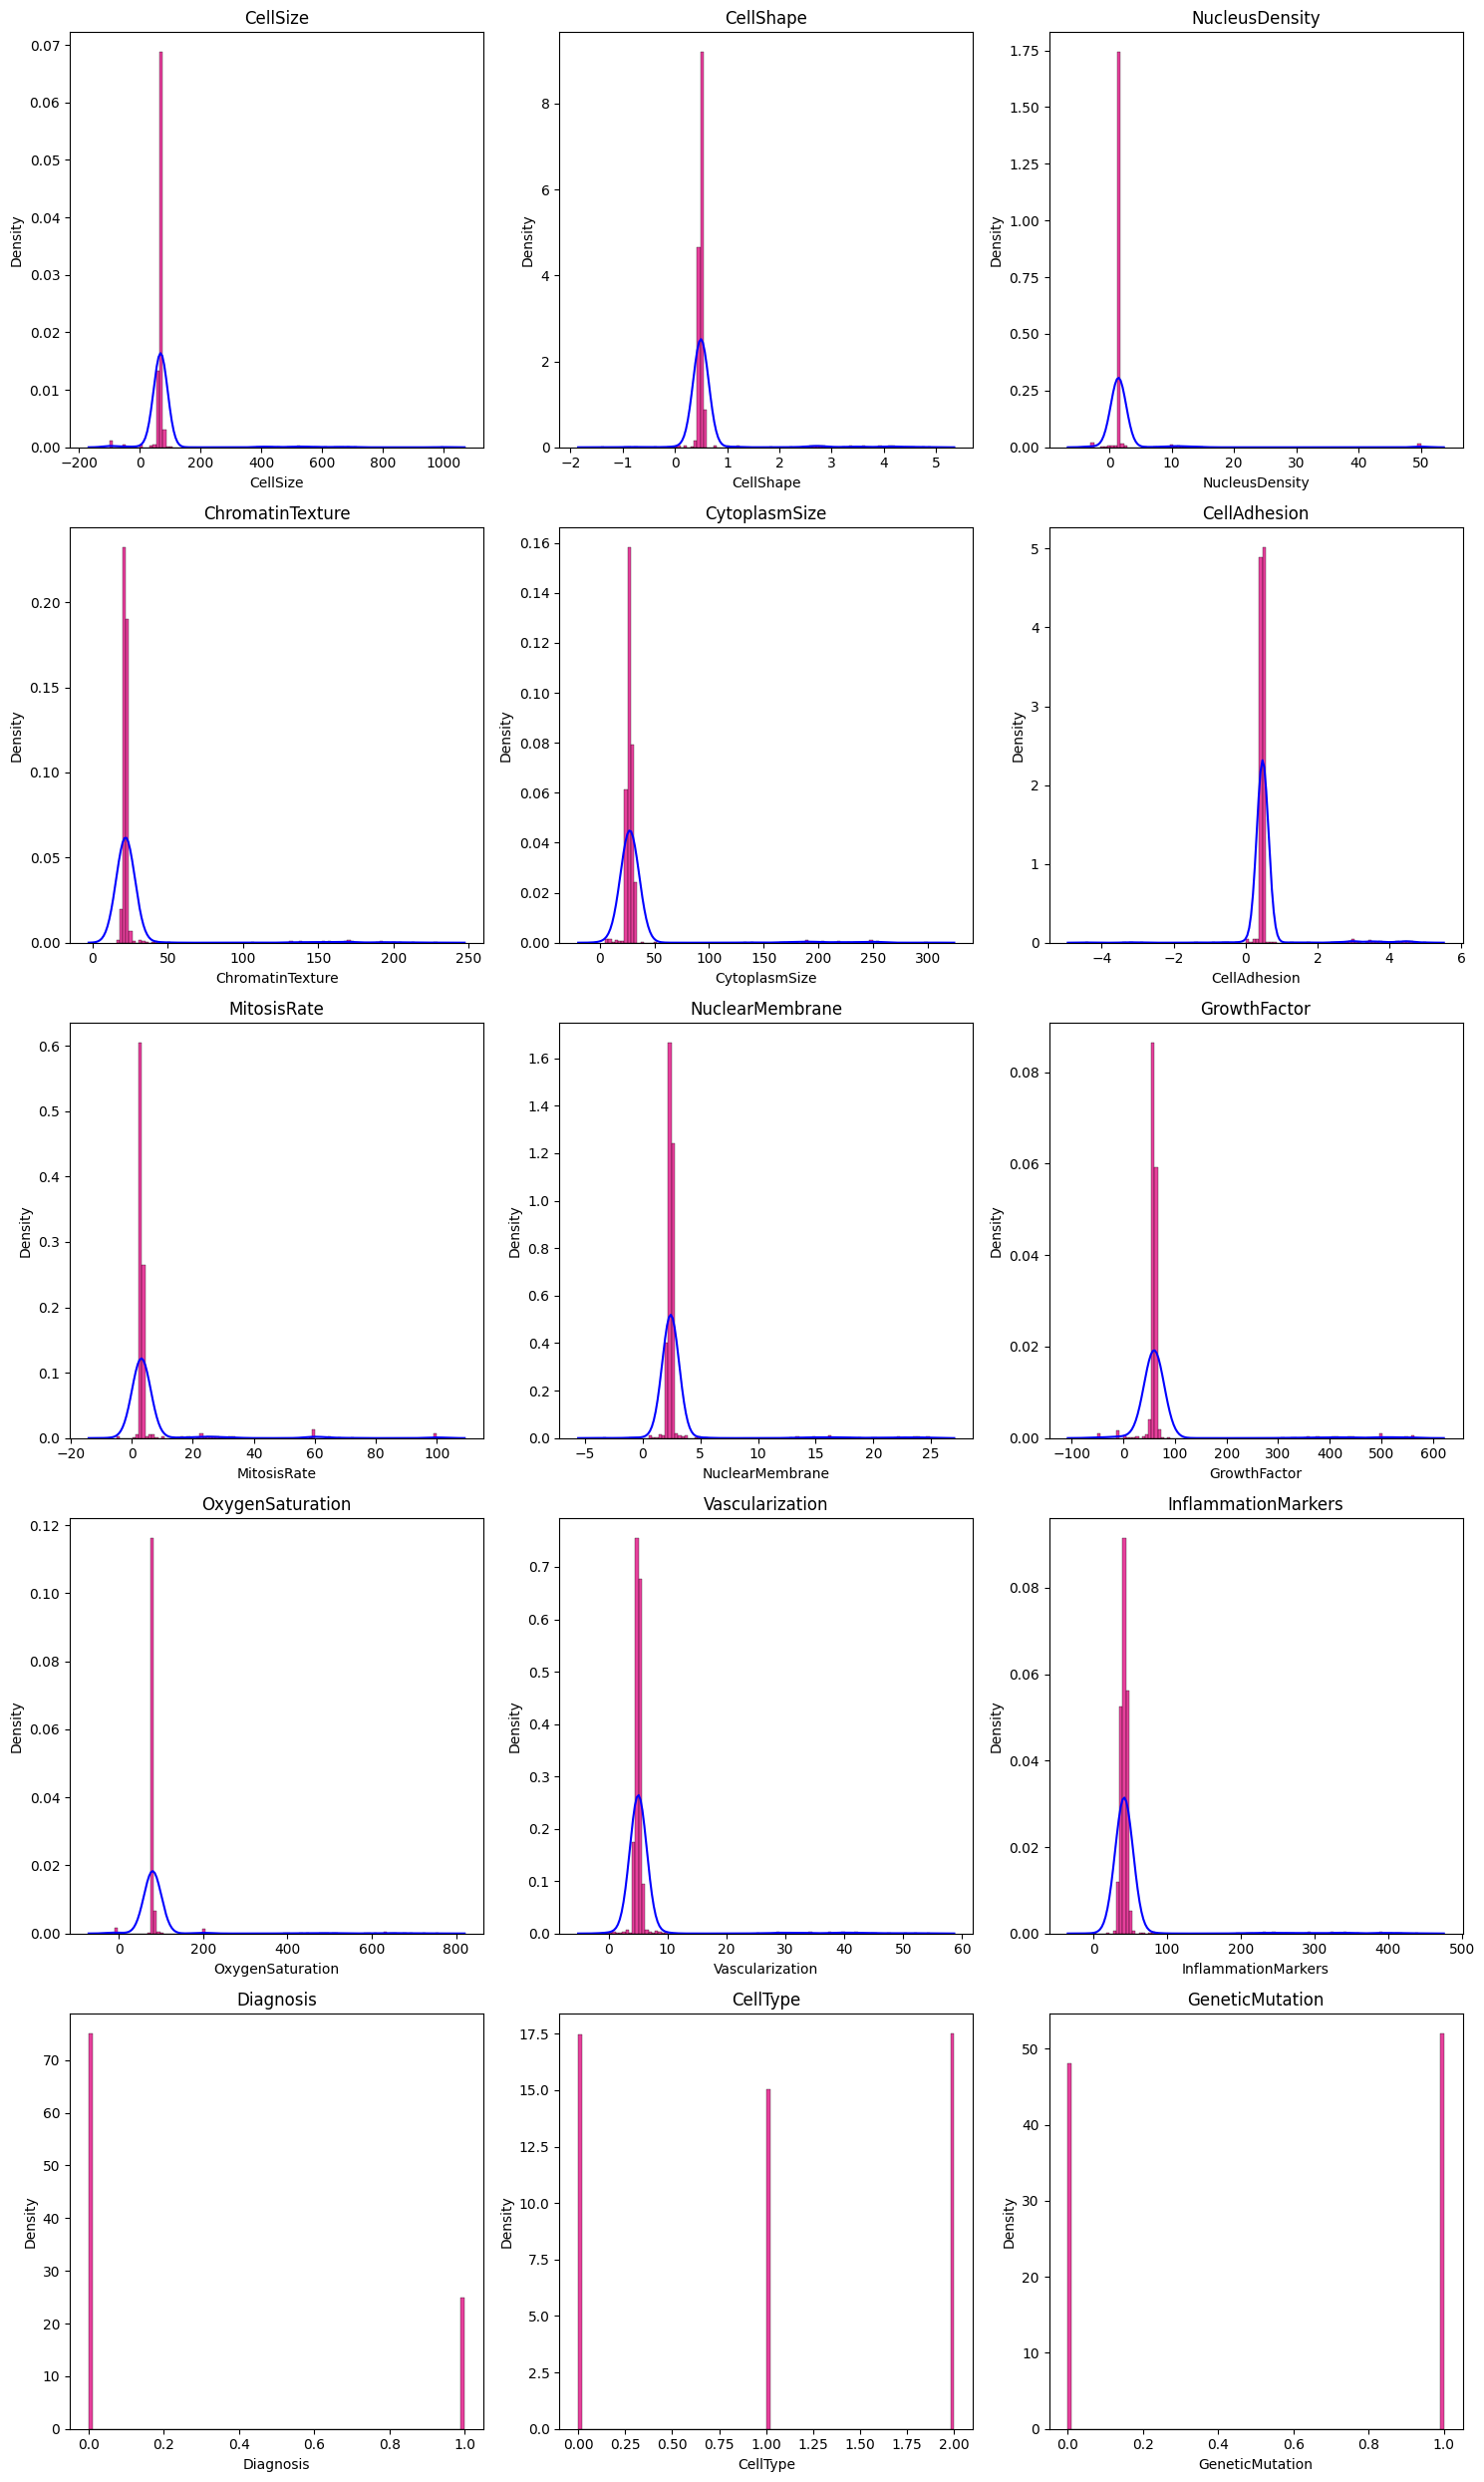

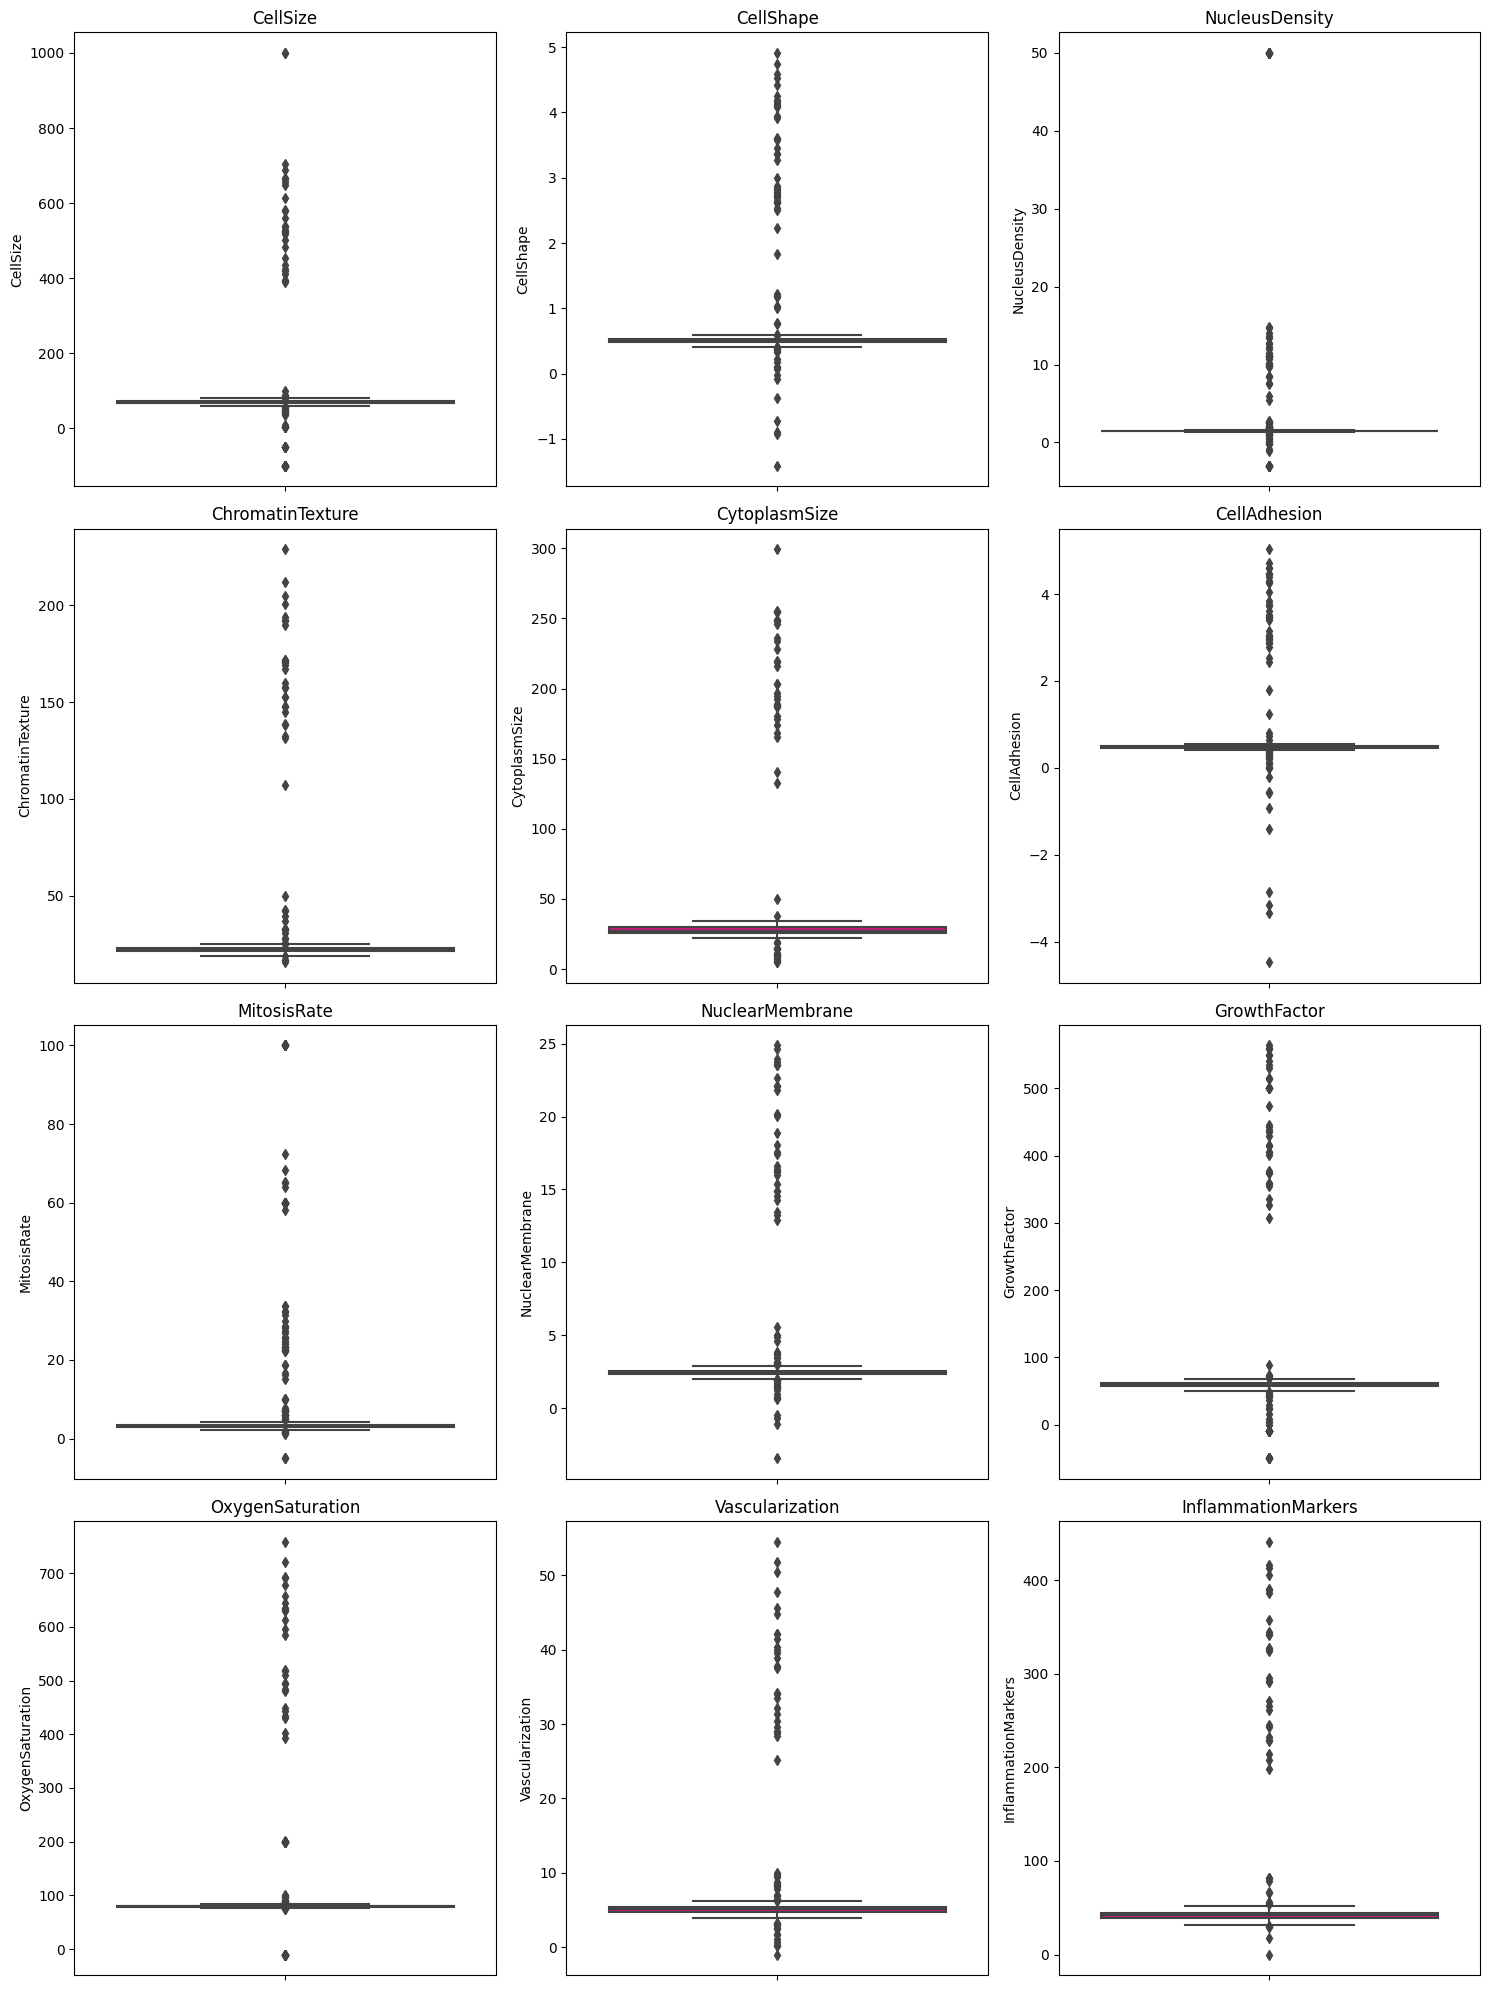

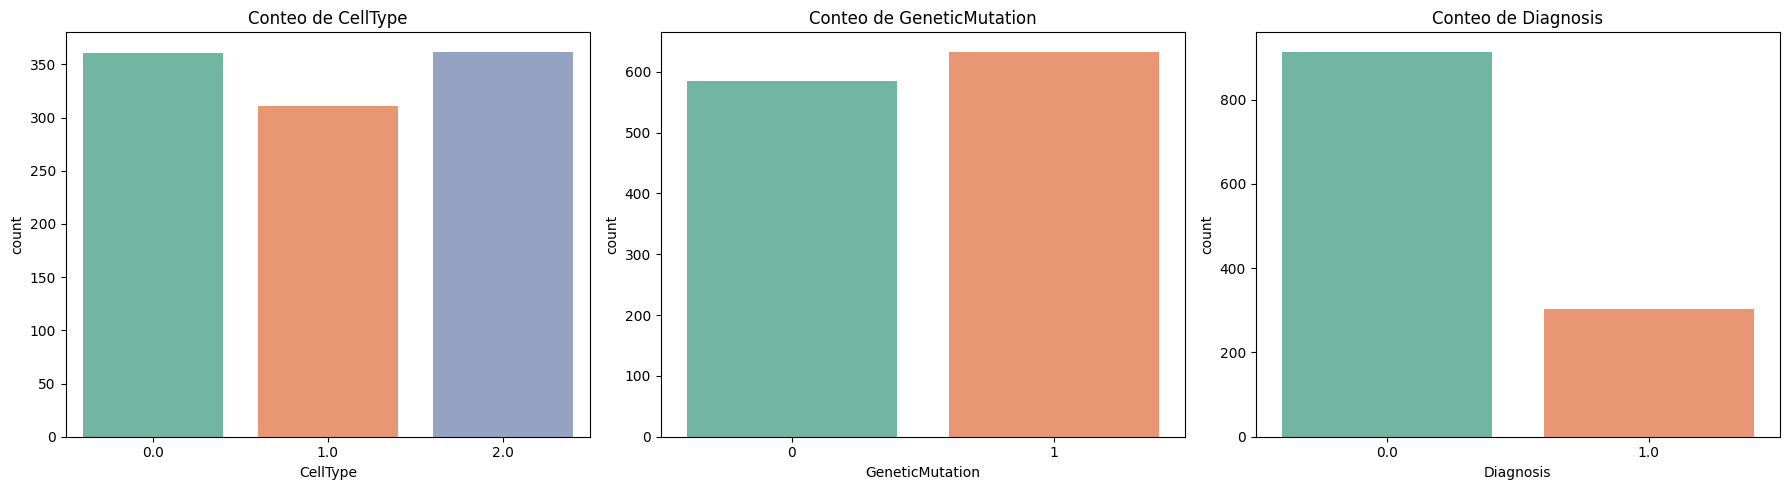

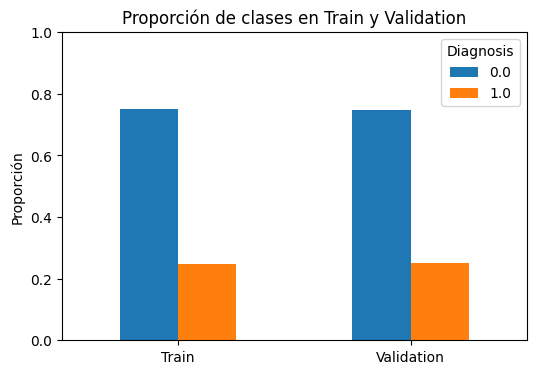

In [9]:
train= pd.read_csv('data/raw/cell_diagnosis_imbalanced_dev.csv')
train=codificar_categoricas(train)

#visualizaciones
print('valores nulos en cada columna:\n', train.isna().sum()) 
print('cantidad de filas totales del dataset:',len(train))
print('cantidad de filas del dataset con NaN',train.isna().any(axis=1).sum()) 
visualizar_distribuciones(train)

X_train, X_val, y_train, y_val, train_df, val_df = split_and_plot_classes(train, target_column='Diagnosis', test_size=0.2)
X_train_imp, y_train_imp, X_val_imp, y_val_imp, train_df_proc, val_df_proc = preprocesar_imputado(train, val_df, numericas, categoricas, target='Diagnosis', k=1)

resultados_modelos = {}


A continuación, entrene distintos modelos de regresión logística binaria con regularización L2, aplicando en cada caso una técnica de rebalanceo distinta:
1) Sin rebalanceo: entrenar el modelo directamente sobre los datos desbalanceados.
2) Undersampling: eliminar muestras de la clase mayoritaria de manera aleatoria
hasta que ambas clases tengan igual proporción.
3) Oversampling mediante duplicación: duplicar muestras de la clase minoritaria
de manera aleatoria, hasta que que ambas clases tengan igual proporción.
4) Oversampling mediante SMOTE (Synthetic Minority Oversampling Technique): hasta que ambas clases tengan igual proporción.
5) Cost re-weighting: en la función de costo, multiplicar los terminos que dependen de las muestras de la clase minoritaria por un factor C =
π2
π1
, donde
π1 es la probabilidad a-priori de la clase minoritoria y π2 el de la clase mayoritaria. Esto efectivamente re-balancea la importancia de tener errores de
clasificacion de ambas clases.

In [10]:
#modelo base
W_base, b_base, y_pred_val_base, prob_fn_base, y_score_val_base, best_lambda_base = entrenar_con_lambda_optimo(
    X_train_imp, y_train_imp, X_val_imp, y_val_imp
)
y_pred_test_base = (prob_fn_base(X_val_imp)[:, 1] >= 0.5).astype(int)
y_score_test_base = prob_fn_base(X_val_imp)

resultados_modelos['Baseline'] = {
    'y_pred': y_pred_test_base,
    'prob': y_score_test_base
}

print(f"Modelo Baseline entrenado con lambda óptimo: {best_lambda_base}")
#modelo undersumpling
class_0_us = train_df_proc[train_df_proc['Diagnosis'] == 0].copy()
class_1_us = train_df_proc[train_df_proc['Diagnosis'] == 1].copy()
class_0_down = class_0_us.sample(n=len(class_1_us), random_state=42).copy()

train_bal_us = pd.concat([class_0_down, class_1_us], axis=0).sample(frac=1, random_state=42).reset_index(drop=True)
X_train_us = train_bal_us.drop(columns=['Diagnosis']).copy()
y_train_us = train_bal_us['Diagnosis'].copy()

W_us, b_us, y_pred_val_us, prob_fn_us, y_score_val_us, best_lambda_us = entrenar_con_lambda_optimo(
    X_train_us, y_train_us, X_val_imp, y_val_imp, lr=0.01, epochs=10000
)
y_pred_test_us = (prob_fn_us(X_val_imp)[:, 1] >= 0.5).astype(int)
y_score_test_us = prob_fn_us(X_val_imp)

resultados_modelos['Undersampling'] = {
    'y_pred': y_pred_test_us,
    'prob': y_score_test_us
}

print(f"Modelo Undersampling entrenado con lambda óptimo: {best_lambda_us}")

#modelo oversampling
class_0_over = train_df_proc[train_df_proc['Diagnosis'] == 0].copy()
class_1_over = train_df_proc[train_df_proc['Diagnosis'] == 1].copy()
max_len_over = max(len(class_0_over), len(class_1_over))

class_1_up = class_1_over.sample(n=max_len_over, replace=True, random_state=42).copy()
train_bal_over = pd.concat([class_0_over, class_1_up], axis=0).sample(frac=1, random_state=42).reset_index(drop=True)
X_train_over = train_bal_over.drop(columns=['Diagnosis']).copy()
y_train_over = train_bal_over['Diagnosis'].copy()

W_over, b_over, y_pred_val_over, prob_fn_over, y_score_val_over, best_lambda_over = entrenar_con_lambda_optimo(
    X_train_over, y_train_over, X_val_imp, y_val_imp, lr=0.01, epochs=10000
)
y_pred_test_over = (prob_fn_over(X_val_imp)[:, 1] >= 0.5).astype(int)
y_score_test_over = prob_fn_over(X_val_imp)

resultados_modelos['Oversampling'] = {
    'y_pred': y_pred_test_over,
    'prob': y_score_test_over
}

print(f"Modelo Oversampling entrenado con lambda óptimo: {best_lambda_over}")

#modelo smote
X_train_smote, y_train_smote = SMOTE(
    X_train_imp.copy(), y_train_imp.copy(), clase_minoritaria=1, random_state=42
)

W_smote, b_smote, y_pred_val_smote, prob_fn_smote, y_score_val_smote, best_lambda_smote = entrenar_con_lambda_optimo(
    X_train_smote, y_train_smote, X_val_imp, y_val_imp, lr=0.01, epochs=10000
)
y_pred_test_smote = (prob_fn_smote(X_val_imp)[:, 1] >= 0.5).astype(int)
y_score_test_smote = prob_fn_smote(X_val_imp)

resultados_modelos['SMOTE'] = {
    'y_pred': y_pred_test_smote,
    'prob': y_score_test_smote
}

print(f"Modelo SMOTE entrenado con lambda óptimo: {best_lambda_smote}")

#modelo costo re-weighting
unique, counts = np.unique(y_train_imp, return_counts=True)
class_counts = dict(zip(unique, counts))
total_samples = len(y_train_imp)

pi_1 = class_counts[1] / total_samples
pi_0 = class_counts[0] / total_samples
C = pi_0 / pi_1

weights_crw = np.array([C if y == 1 else 1.0 for y in y_train_imp])

W_crw, b_crw, y_pred_val_crw, prob_fn_crw, y_score_val_crw, best_lambda_crw = entrenar_con_lambda_optimo(
    X_train_imp.copy(), y_train_imp.copy(), X_val_imp, y_val_imp, lr=0.01, epochs=10000, sample_weights=weights_crw
)
y_pred_test_crw = (prob_fn_crw(X_val_imp)[:, 1] >= 0.5).astype(int)
y_score_test_crw = prob_fn_crw(X_val_imp)

resultados_modelos['Cost Re-weighting'] = {
    'y_pred': y_pred_test_crw,
    'prob': y_score_test_crw
}

print(f"Modelo Cost Re-weighting entrenado con lambda óptimo: {best_lambda_crw}")



Mejor lambda: 0.0001, F1=0.8693
Modelo Baseline entrenado con lambda óptimo: 0.0001

Mejor lambda: 0.0001, F1=0.9032
Modelo Undersampling entrenado con lambda óptimo: 0.0001

Mejor lambda: 0.0001, F1=0.9032
Modelo Oversampling entrenado con lambda óptimo: 0.0001

Mejor lambda: 8.282845454545454, F1=0.8969
Modelo SMOTE entrenado con lambda óptimo: 8.282845454545454

Mejor lambda: 0.0001, F1=0.9032
Modelo Cost Re-weighting entrenado con lambda óptimo: 0.0001


              Modelo  Accuracy  Precision  Recall  F1-Score  AUC-ROC  AUC-PR
0           Baseline    0.8971     0.8566  0.8823    0.8693   0.9540  0.8046
1      Undersampling    0.9136     0.8719  0.9369    0.9032   0.9551  0.8136
2       Oversampling    0.9136     0.8719  0.9369    0.9032   0.9550  0.8187
3              SMOTE    0.9095     0.8673  0.9287    0.8969   0.9556  0.8156
4  Cost Re-weighting    0.9136     0.8719  0.9369    0.9032   0.9542  0.8110
              Modelo  TP   TN  FP  FN
0           Baseline  52  166  16   9
1      Undersampling  60  162  20   1
2       Oversampling  60  162  20   1
3              SMOTE  59  162  20   2
4  Cost Re-weighting  60  162  20   1


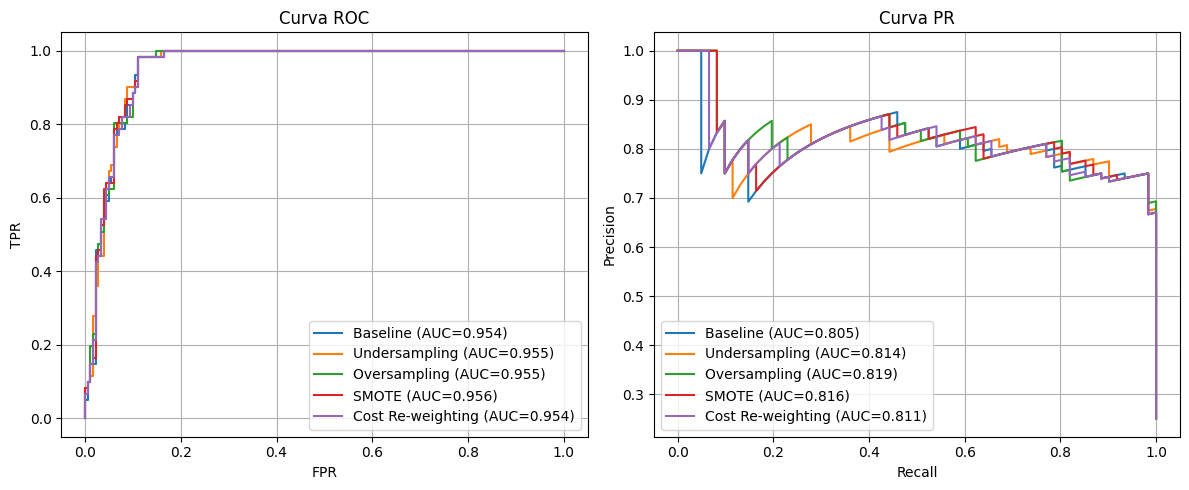

In [11]:
modelos = ['Baseline', 'Undersampling', 'Oversampling', 'SMOTE', 'Cost Re-weighting']
tabla_resultados = []

for modelo in modelos:
    res = resultados_modelos[modelo]
    y_pred = np.array(res['y_pred'], dtype=int)[:len(y_val_imp)]
    y_score = get_prob_positiva(np.array(res['prob'], dtype=float)[:len(y_val_imp)])
    y_true = np.array(y_val_imp, dtype=int)
    fpr_list, tpr_list, recall_list, precision_list = calc_roc_pr(y_true, y_score)
    acc = accuracy(y_true, y_pred)
    prec = precision(y_true, y_pred)
    rec = recall(y_true, y_pred)
    f1 = f1_score_manual(y_true, y_pred)
    auc_roc = auc_trapecio(fpr_list, tpr_list)
    auc_pr = auc_trapecio(recall_list, precision_list)
    tp = np.sum((y_true == 1) & (y_pred == 1))
    tn = np.sum((y_true == 0) & (y_pred == 0))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))
    tabla_resultados.append({
        'Modelo': modelo,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1,
        'AUC-ROC': auc_roc,
        'AUC-PR': auc_pr,
        'TP': tp,
        'TN': tn,
        'FP': fp,
        'FN': fn
    })

df_resultados = pd.DataFrame(tabla_resultados)

print(df_resultados[['Modelo', 'Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC', 'AUC-PR']].round(4))
print(df_resultados[['Modelo', 'TP', 'TN', 'FP', 'FN']])

plt.figure(figsize=(12,5))


for i, curve_type in enumerate(['ROC','PR'], start=1):
    plt.subplot(1,2,i)
    for modelo in modelos:
        res = resultados_modelos[modelo]
        y_true = np.array(y_val_imp, dtype=int)
        y_score = get_prob_positiva(np.array(res['prob'], dtype=float)[:len(y_val_imp)])
        fpr_list, tpr_list, recall_list, precision_list = calc_roc_pr(y_true, y_score)
        fpr_list = np.array(fpr_list) #las recorto porque si no no me deja plotear
        tpr_list = np.array(tpr_list)
        recall_list = np.array(recall_list)
        precision_list = np.array(precision_list)

        if curve_type == 'ROC':
            min_len = min(len(fpr_list), len(tpr_list))
            plt.plot(fpr_list[:min_len], tpr_list[:min_len],
                     label=f'{modelo} (AUC={auc_trapecio(fpr_list[:min_len], tpr_list[:min_len]):.3f})')
            plt.xlabel('FPR')
            plt.ylabel('TPR')
            plt.title('Curva ROC')
        else:
            min_len = min(len(recall_list), len(precision_list))
            plt.plot(recall_list[:min_len], precision_list[:min_len],
                     label=f'{modelo} (AUC={auc_trapecio(recall_list[:min_len], precision_list[:min_len]):.3f})')
            plt.xlabel('Recall')
            plt.ylabel('Precision')
            plt.title('Curva PR')

    plt.legend()
    plt.grid(True)

plt.tight_layout()
plt.show()

Utilizando el conjunto de datos de test cell_diagnosis_imbalanced_test.csv,
evalúe la performance de cada modelo desarrollado anteriormente, computando
las métricas del inciso 1.4.

              Modelo  Accuracy  Precision  Recall  F1-Score  AUC-ROC  AUC-PR
0           Baseline    0.9044     0.8813  0.8578    0.8694   0.9544  0.8000
1      Undersampling    0.9265     0.8967  0.9118    0.9042   0.9573  0.8135
2       Oversampling    0.9265     0.8967  0.9118    0.9042   0.9544  0.8181
3              SMOTE    0.9265     0.8967  0.9118    0.9042   0.9556  0.8248
4  Cost Re-weighting    0.9265     0.8967  0.9118    0.9042   0.9544  0.8072
              Modelo  TP  TN  FP  FN
0           Baseline  26  97   5   8
1      Undersampling  30  96   6   4
2       Oversampling  30  96   6   4
3              SMOTE  30  96   6   4
4  Cost Re-weighting  30  96   6   4


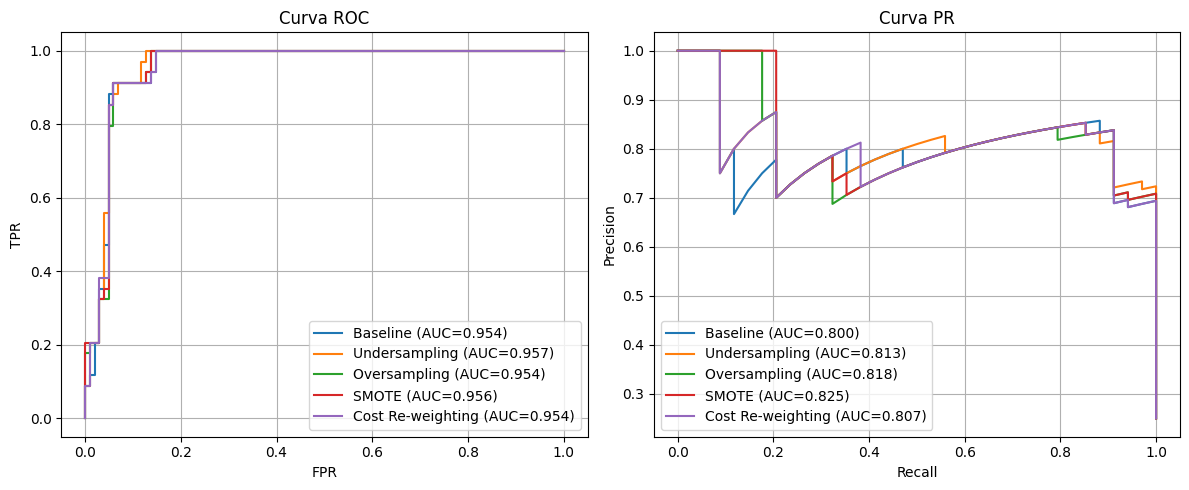

In [12]:
train = pd.read_csv('data/raw/cell_diagnosis_imbalanced_dev.csv')
train = codificar_categoricas(train)
test = pd.read_csv('data/raw/cell_diagnosis_imbalanced_test.csv')
test = codificar_categoricas(test)

X_train_imp, y_train_imp, X_val_imp, y_val_imp, train_df_proc, val_df_proc = preprocesar_imputado(
    train, test, numericas, categoricas, target='Diagnosis', k=1
)

resultados_modelos = {}

#modelo desbalanceado
W_base, b_base, y_pred_base_test, prob_base_fn = logistic_regression(
    X_train_imp, y_train_imp, X_val_imp,
    lr=0.01, epochs=10000, reg_lambda=0
)
y_score_base_test = prob_base_fn(X_val_imp)
resultados_modelos['Baseline'] = {'y_pred': y_pred_base_test, 'prob': y_score_base_test}

#modelo undersampling
class_0_us = train_df_proc[train_df_proc['Diagnosis']==0]
class_1_us = train_df_proc[train_df_proc['Diagnosis']==1]  
class_0_down = class_0_us.sample(n=len(class_1_us), random_state=42)
train_bal = pd.concat([class_0_down, class_1_us]).sample(frac=1, random_state=42).reset_index(drop=True)
X_train_bal = train_bal.drop(columns=['Diagnosis'])
y_train_bal = train_bal['Diagnosis']

W_us, b_us, y_pred_us_test, prob_us_fn = logistic_regression(
    X_train_bal, y_train_bal, X_val_imp,
    lr=0.01, epochs=10000, reg_lambda=0
)
y_score_us_test = prob_us_fn(X_val_imp)
resultados_modelos['Undersampling'] = {'y_pred': y_pred_us_test, 'prob': y_score_us_test}

#modelo oversampling
class_0_over = train_df_proc[train_df_proc['Diagnosis'] == 0] 
class_1_over = train_df_proc[train_df_proc['Diagnosis'] == 1] 
max_len = max(len(class_0_over), len(class_1_over))
class_1_up = class_1_over.sample(n=max_len, replace=True, random_state=42)
train_balanced_over = pd.concat([class_0_over, class_1_up]).sample(frac=1, random_state=42).reset_index(drop=True)
X_train_over = train_balanced_over.drop(columns=['Diagnosis'])
y_train_over = train_balanced_over['Diagnosis']

W_overs, b_overs, y_pred_overs_test, prob_fn_oversampling = logistic_regression(
    X_train_over, y_train_over, X_val_imp,
    lr=0.01, epochs=10000, reg_lambda=0
)
y_score_oversampling_test = prob_fn_oversampling(X_val_imp)
resultados_modelos['Oversampling'] = {'y_pred': y_pred_overs_test, 'prob': y_score_oversampling_test}

#modelo smote
X_train_smote, y_train_smote = SMOTE(X_train_imp, y_train_imp, clase_minoritaria=1, random_state=42)

W_smote, b_smote, y_pred_smote_test, prob_fn_smote = logistic_regression(
    X_train_smote, y_train_smote, X_val_imp,
    lr=0.01, epochs=10000, reg_lambda=0
)
y_score_smote_test = prob_fn_smote(X_val_imp)
resultados_modelos['SMOTE'] = {'y_pred': y_pred_smote_test, 'prob': y_score_smote_test}

#modelo cost re-weighting
unique, counts = np.unique(y_train_imp, return_counts=True)
class_counts = dict(zip(unique, counts))
total_samples = len(y_train_imp)
pi_1 = class_counts[1] / total_samples 
pi_2 = class_counts[0] / total_samples  
C = pi_2 / pi_1
weights = np.array([C if y == 1 else 1.0 for y in y_train_imp])  

W_pesos, b_pesos, y_pred_pesos_test, prob_fn_pesos = logistic_regression(
    X_train_imp, y_train_imp, X_val_imp,
    lr=0.01, epochs=10000, reg_lambda=0, sample_weights=weights
)
y_score_pesos_test = prob_fn_pesos(X_val_imp)
resultados_modelos['Cost Re-weighting'] = {'y_pred': y_pred_pesos_test, 'prob': y_score_pesos_test}

#evalucacion de modelos
modelos = ['Baseline', 'Undersampling', 'Oversampling', 'SMOTE', 'Cost Re-weighting']
tabla_resultados = []

for modelo in modelos:
    res = resultados_modelos[modelo]
    y_pred = np.array(res['y_pred'], dtype=int)[:len(y_val_imp)]
    y_score = get_prob_positiva(np.array(res['prob'], dtype=float)[:len(y_val_imp)])
    y_true = np.array(y_val_imp, dtype=int)
    fpr_list, tpr_list, recall_list, precision_list = calc_roc_pr(y_true, y_score)
    acc = accuracy(y_true, y_pred)
    prec = precision(y_true, y_pred)
    rec = recall(y_true, y_pred)
    f1 = f1_score_manual(y_true, y_pred)
    auc_roc = auc_trapecio(fpr_list, tpr_list)
    auc_pr = auc_trapecio(recall_list, precision_list)
    tp = np.sum((y_true == 1) & (y_pred == 1))
    tn = np.sum((y_true == 0) & (y_pred == 0))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))
    tabla_resultados.append({
        'Modelo': modelo,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1,
        'AUC-ROC': auc_roc,
        'AUC-PR': auc_pr,
        'TP': tp,
        'TN': tn,
        'FP': fp,
        'FN': fn
    })

df_resultados = pd.DataFrame(tabla_resultados)

print(df_resultados[['Modelo', 'Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC', 'AUC-PR']].round(4))
print(df_resultados[['Modelo', 'TP', 'TN', 'FP', 'FN']])

#graficos
plt.figure(figsize=(12,5))

for i, curve_type in enumerate(['ROC','PR'], start=1):
    plt.subplot(1,2,i)
    for modelo in modelos:
        res = resultados_modelos[modelo]
        y_true = np.array(y_val_imp, dtype=int)
        y_score = get_prob_positiva(np.array(res['prob'], dtype=float)[:len(y_val_imp)])
        fpr_list, tpr_list, recall_list, precision_list = calc_roc_pr(y_true, y_score)
        fpr_list = np.array(fpr_list) #las recorto porque si no no me deja plotear
        tpr_list = np.array(tpr_list)
        recall_list = np.array(recall_list)
        precision_list = np.array(precision_list)

        if curve_type == 'ROC':
            min_len = min(len(fpr_list), len(tpr_list))
            plt.plot(fpr_list[:min_len], tpr_list[:min_len],
                     label=f'{modelo} (AUC={auc_trapecio(fpr_list[:min_len], tpr_list[:min_len]):.3f})')
            plt.xlabel('FPR')
            plt.ylabel('TPR')
            plt.title('Curva ROC')
        else:
            min_len = min(len(recall_list), len(precision_list))
            plt.plot(recall_list[:min_len], precision_list[:min_len],
                     label=f'{modelo} (AUC={auc_trapecio(recall_list[:min_len], precision_list[:min_len]):.3f})')
            plt.xlabel('Recall')
            plt.ylabel('Precision')
            plt.title('Curva PR')
    plt.legend()
    plt.grid(True)
plt.tight_layout()
plt.show()

Analice los resultados obtenidos y discuta cuál de los modelos implementaría en
un entorno de producción. Justifique su elección en base a las métricas observadas
y al comportamiento de los modelos.


Analizando los resultados obtenidos, en un entorno de produccion implementaria el modelo entrenado sobre el dataset imputado, ya que este cuenta con un conjunto de validacion mas grande y representativo, lo que le otorga mayor confiabilidad frente a los modelos que eliminan las filas con valores faltantes. Ademas, se obtienen valores similares entre validacion y test, lo que indica que el modelo es capaz de generalizar de manera eficiente ante datos no vistos anteriormente. Entre los distintos enfoques probados para manejar el desbalance de clases, eligiria el modelo con cost re-weighting que penaliza las clases minoritarias, lo que lo hace mas robusto frente a datos desbalanceados.